In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import scipy

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, confusion_matrix

# Patch: tambahkan atribut interp ke scipy
scipy.interp = np.interp
import scikitplot as skplt

from imblearn.over_sampling import SMOTE

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [207]:
df_Apptrain = pd.read_csv("G:/PROJECT/Rakamin/home-credit-default-risk/application_train.csv")
df_Apptest = pd.read_csv("G:/PROJECT/Rakamin/home-credit-default-risk/application_test.csv")

df_Bureau = pd.read_csv("G:/PROJECT/Rakamin/home-credit-default-risk/bureau.csv")
df_Bureau_balance = pd.read_csv("G:/PROJECT/Rakamin/home-credit-default-risk/bureau_balance.csv")

df_Credit_card_balance = pd.read_csv("G:/PROJECT/Rakamin/home-credit-default-risk/credit_card_balance.csv")
df_Installments_payments = pd.read_csv("G:/PROJECT/Rakamin/home-credit-default-risk/installments_payments.csv")
df_POS_CASH_balance = pd.read_csv("G:/PROJECT/Rakamin/home-credit-default-risk/POS_CASH_balance.csv")
df_Previous_application = pd.read_csv("G:/PROJECT/Rakamin/home-credit-default-risk/previous_application.csv")

In [4]:
df_Apptrain.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
df_Apptrain.shape

(307511, 122)

In [6]:
df_Apptrain.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [7]:
missing_data = df_Apptrain.isnull().sum().sort_values(ascending=False)
missing_data = pd.DataFrame(missing_data, columns=['Missing Count'])
missing_data['Missing Percentage (%)'] = (missing_data['Missing Count'] / len(df_Apptrain)) * 100
display(missing_data)

,Missing Count,Missing Percentage (%)
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [8]:
x = df_Apptrain.drop('TARGET', axis=1)
y = df_Apptrain['TARGET']

In [9]:
df_Apptrain_copy =df_Apptrain.copy()

In [10]:
df_Appnull = pd.DataFrame(x.isnull().sum()/len(df_Apptrain_copy)*100, columns=['Missing Percentage'])
df_Appnull.sort_values(by='Missing Percentage', ascending=False)

df_Appnull = df_Appnull[df_Appnull['Missing Percentage'] < 15]
df_Appnull = df_Appnull.reset_index()
df_Appnull = df_Appnull.rename(columns={'index': 'feature'})
display(df_Appnull)

,feature,Missing Percentage
0,SK_ID_CURR,0.000000
1,NAME_CONTRACT_TYPE,0.000000
2,CODE_GENDER,0.000000
3,FLAG_OWN_CAR,0.000000
4,FLAG_OWN_REALTY,0.000000
5,CNT_CHILDREN,0.000000
6,AMT_INCOME_TOTAL,0.000000
7,AMT_CREDIT,0.000000
8,AMT_ANNUITY,0.003902
9,AMT_GOODS_PRICE,0.090403


In [11]:
col = df_Appnull['feature'].to_list()

x=x[col]
df_Apptest = df_Apptest[col]

In [12]:
x.shape, df_Apptest.shape, y.shape

((307511, 70), (48744, 70), (307511,))

##Exploratory Data Analysis (EDA)

In [13]:
EDA = x.copy()

In [14]:
num = EDA.select_dtypes(include='number').columns
cat = EDA.select_dtypes(include='object').columns

In [15]:
EDA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 70 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   NAME_CONTRACT_TYPE           307511 non-null  object 
 2   CODE_GENDER                  307511 non-null  object 
 3   FLAG_OWN_CAR                 307511 non-null  object 
 4   FLAG_OWN_REALTY              307511 non-null  object 
 5   CNT_CHILDREN                 307511 non-null  int64  
 6   AMT_INCOME_TOTAL             307511 non-null  float64
 7   AMT_CREDIT                   307511 non-null  float64
 8   AMT_ANNUITY                  307499 non-null  float64
 9   AMT_GOODS_PRICE              307233 non-null  float64
 10  NAME_TYPE_SUITE              306219 non-null  object 
 11  NAME_INCOME_TYPE             307511 non-null  object 
 12  NAME_EDUCATION_TYPE          307511 non-null  object 
 13 

In [16]:
EDA[num].describe(include='all').round(2)

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_2,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.00,307511.00,3.075110e+05,307511.00,307499.00,307233.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.0,307511.00,307511.0,307511.00,307511.00,307511.00,307509.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,306851.00,306490.00,306490.00,306490.00,306490.00,307510.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.0,307511.00,307511.0,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,265992.00,265992.00,265992.00,265992.00,265992.00,265992.00
mean,278180.52,0.42,1.687979e+05,599026.00,27108.57,538396.21,0.02,-16037.00,63815.05,-4986.12,-2994.20,1.0,0.82,0.2,1.00,0.28,0.06,2.15,2.05,2.03,12.06,0.02,0.05,0.04,0.08,0.23,0.18,0.51,1.42,0.14,1.41,0.10,-962.86,0.00,0.71,0.00,0.02,0.09,0.00,0.08,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.01,0.00,0.01,0.00,0.00,0.00,0.01,0.01,0.03,0.27,0.27,1.90
std,102790.18,0.72,2.371231e+05,402490.78,14493.74,369446.46,0.01,4363.99,141275.77,3522.89,1509.45,0.0,0.38,0.4,0.04,0.45,0.23,0.91,0.51,0.50,3.27,0.12,0.22,0.20,0.27,0.42,0.38,0.19,2.40,0.45,2.38,0.36,826.81,0.01,0.45,0.01,0.12,0.28,0.01,0.27,0.06,0.0,0.06,0.0,0.06,0.05,0.03,0.10,0.02,0.09,0.02,0.02,0.02,0.08,0.11,0.20,0.92,0.79,1.87
min,100002.00,0.00,2.565000e+04,45000.00,1615.50,40500.00,0.00,-25229.00,-17912.00,-24672.00,-7197.00,0.0,0.00,0.0,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-4292.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,189145.50,0.00,1.125000e+05,270000.00,16524.00,238500.00,0.01,-19682.00,-2760.00,-7479.50,-4299.00,1.0,1.00,0.0,1.00,0.00,0.00,2.00,2.00,2.00,10.00,0.00,0.00,0.00,0.00,0.00,0.00,0.39,0.00,0.00,0.00,0.00,-1570.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,278202.00,0.00,1.471500e+05,513531.00,24903.00,450000.00,0.02,-15750.00,-1213.00,-4504.00,-3254.00,1.0,1.00,0.0,1.00,0.00,0.00,2.00,2.00,2.00,12.00,0.00,0.00,0.00,0.00,0.00,0.00,0.57,0.00,0.00,0.00,0.00,-757.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
75%,367142.50,1.00,2.025000e+05,808650.00,34596.00,679500.00,0.03,-12413.00,-289.00,-2010.00,-1720.00,1.0,1.00,0.0,1.00,1.00,0.00,3.00,2.00,2.00,14.00,0.00,0.00,0.00,0.00,0.00,0.00,0.66,2.00,0.00,2.00,0.00,-274.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00
max,456255.00,19.00,1.170000e+08,4050000.00,258025.50,4050000.00,0.07,-7489.00,365243.00,0.00,0.00,1.0,1.00,1.0,1.00,1.00,1.00,20.00,3.00,3.00,23.00,1.00,1.00,1.00,1.00,1.00,1.00,0.85,348.00,34.00,344.00,24.00,0.00,1.00,1.00,1.00,1.00,1

In [17]:
EDA[cat].describe(include='all').round(2)

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE
count,307511,307511,307511,307511,306219,307511,307511,307511,307511,307511,307511
unique,2,3,2,2,7,8,5,6,6,7,58
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,TUESDAY,Business Entity Type 3
freq,278232,202448,202924,213312,248526,158774,218391,196432,272868,53901,67992


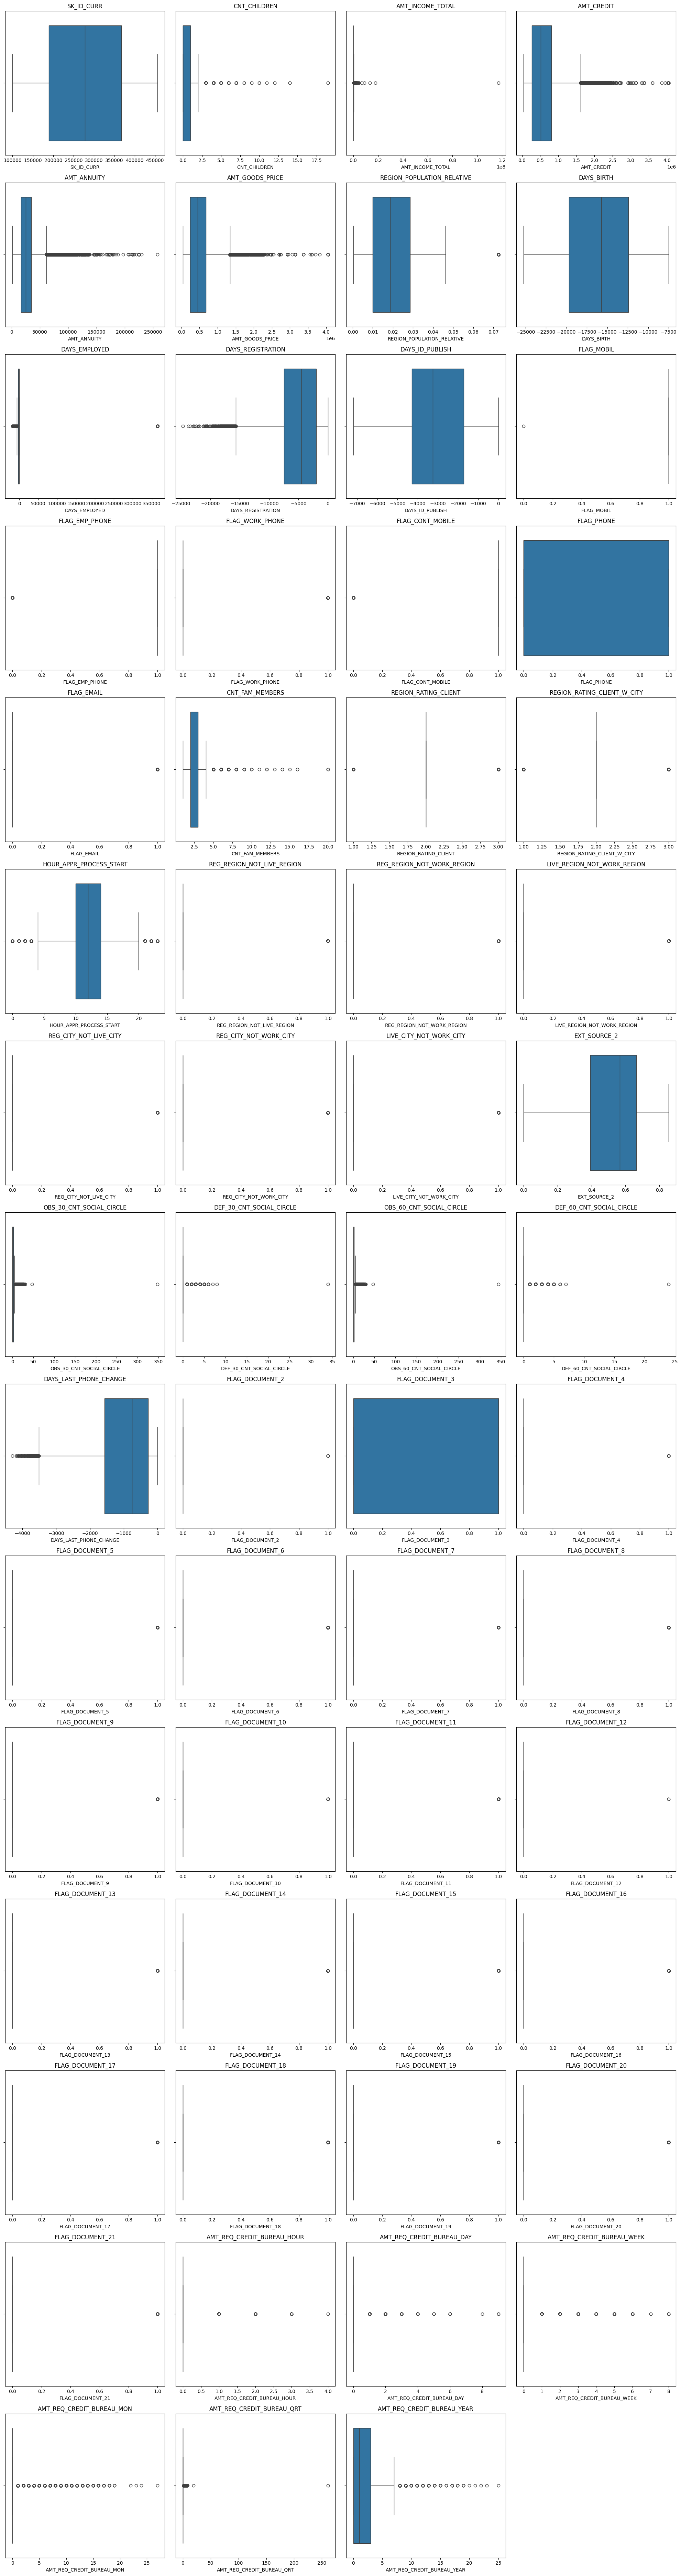

In [18]:
n_cols = 4
n_rows = (len(num) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, feature in enumerate(num):
    sns.boxplot(x=EDA[feature], ax=axes[i])
    axes[i].set_title(feature)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

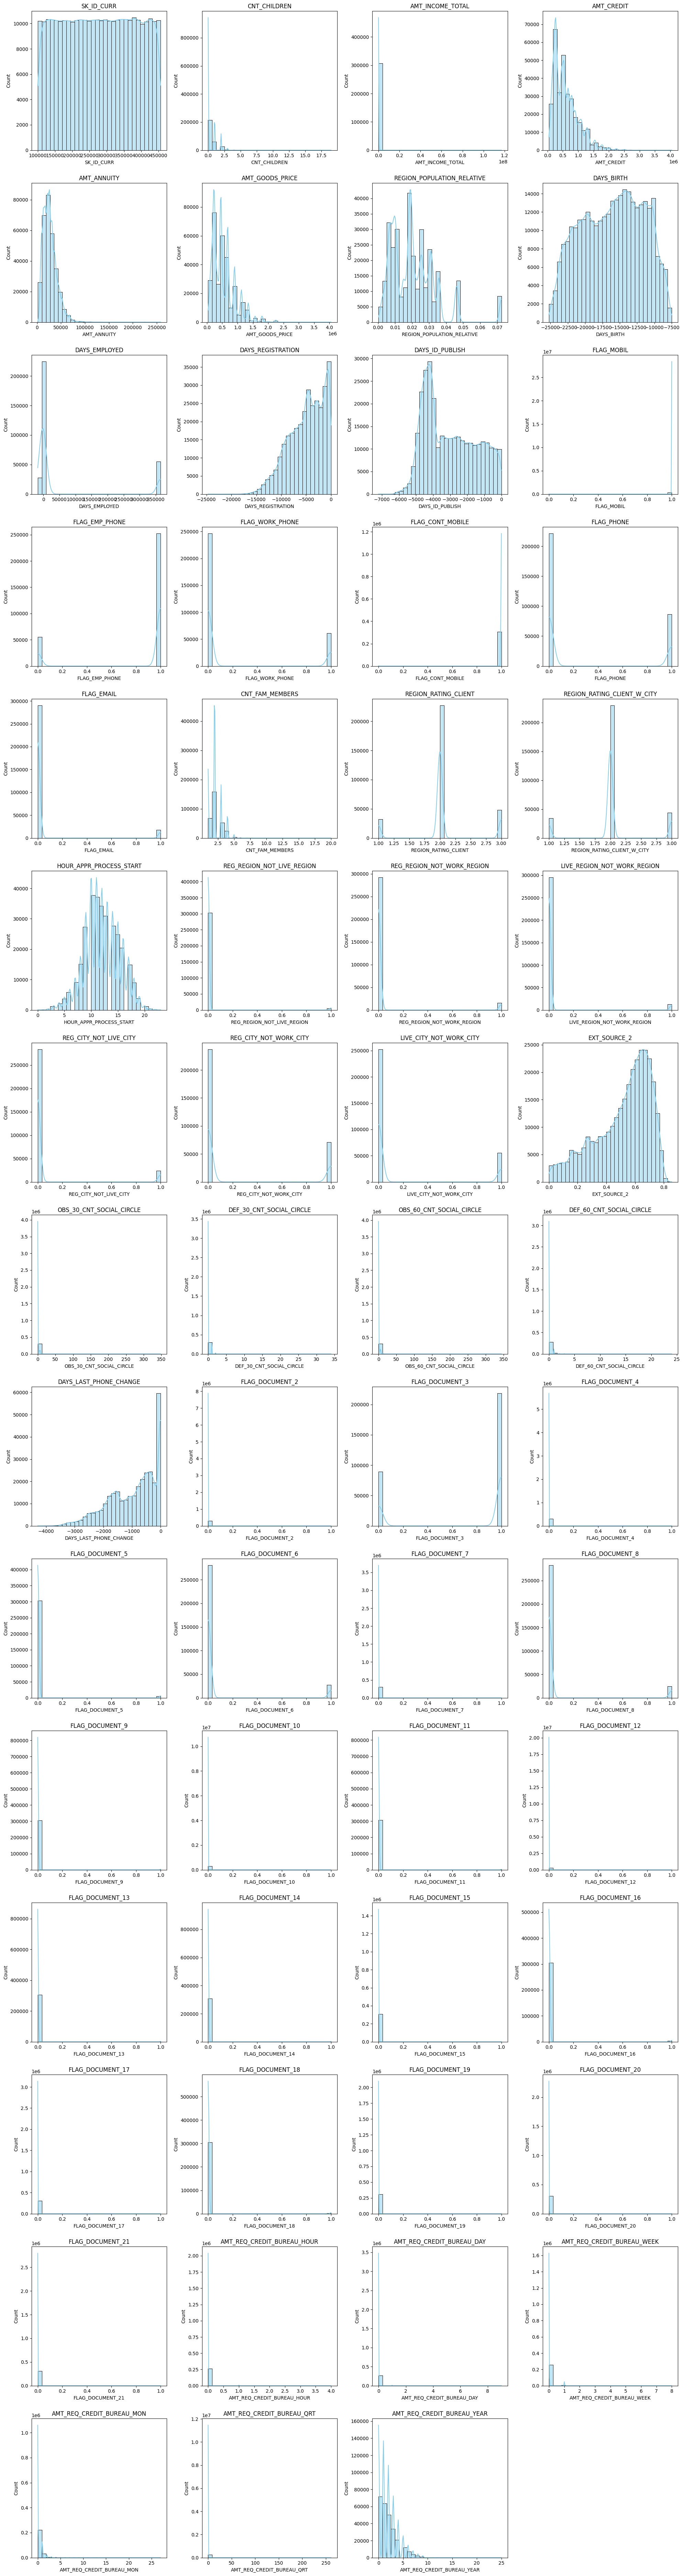

In [19]:
n_cols = 4
n_rows = (len(num) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, columns in enumerate(num):
    sns.histplot(EDA[columns], bins=30, kde=True, color='skyblue', ax=axes[i])
    axes[i].set_title(columns)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [20]:
EDA_y = pd.concat([EDA, y], axis=1)

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\1316575914.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=EDA_y, x=columns, hue='TARGET', fill=True, ax=axes[i])
C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\1316575914.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=EDA_y, x=columns, hue='TARGET', fill=True, ax=axes[i])
C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\1316575914.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=EDA_y, x=columns, hue='TARGET', fill=True, ax=axes[i])
C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\1316575914.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=EDA_y, x=columns, hue='TARG

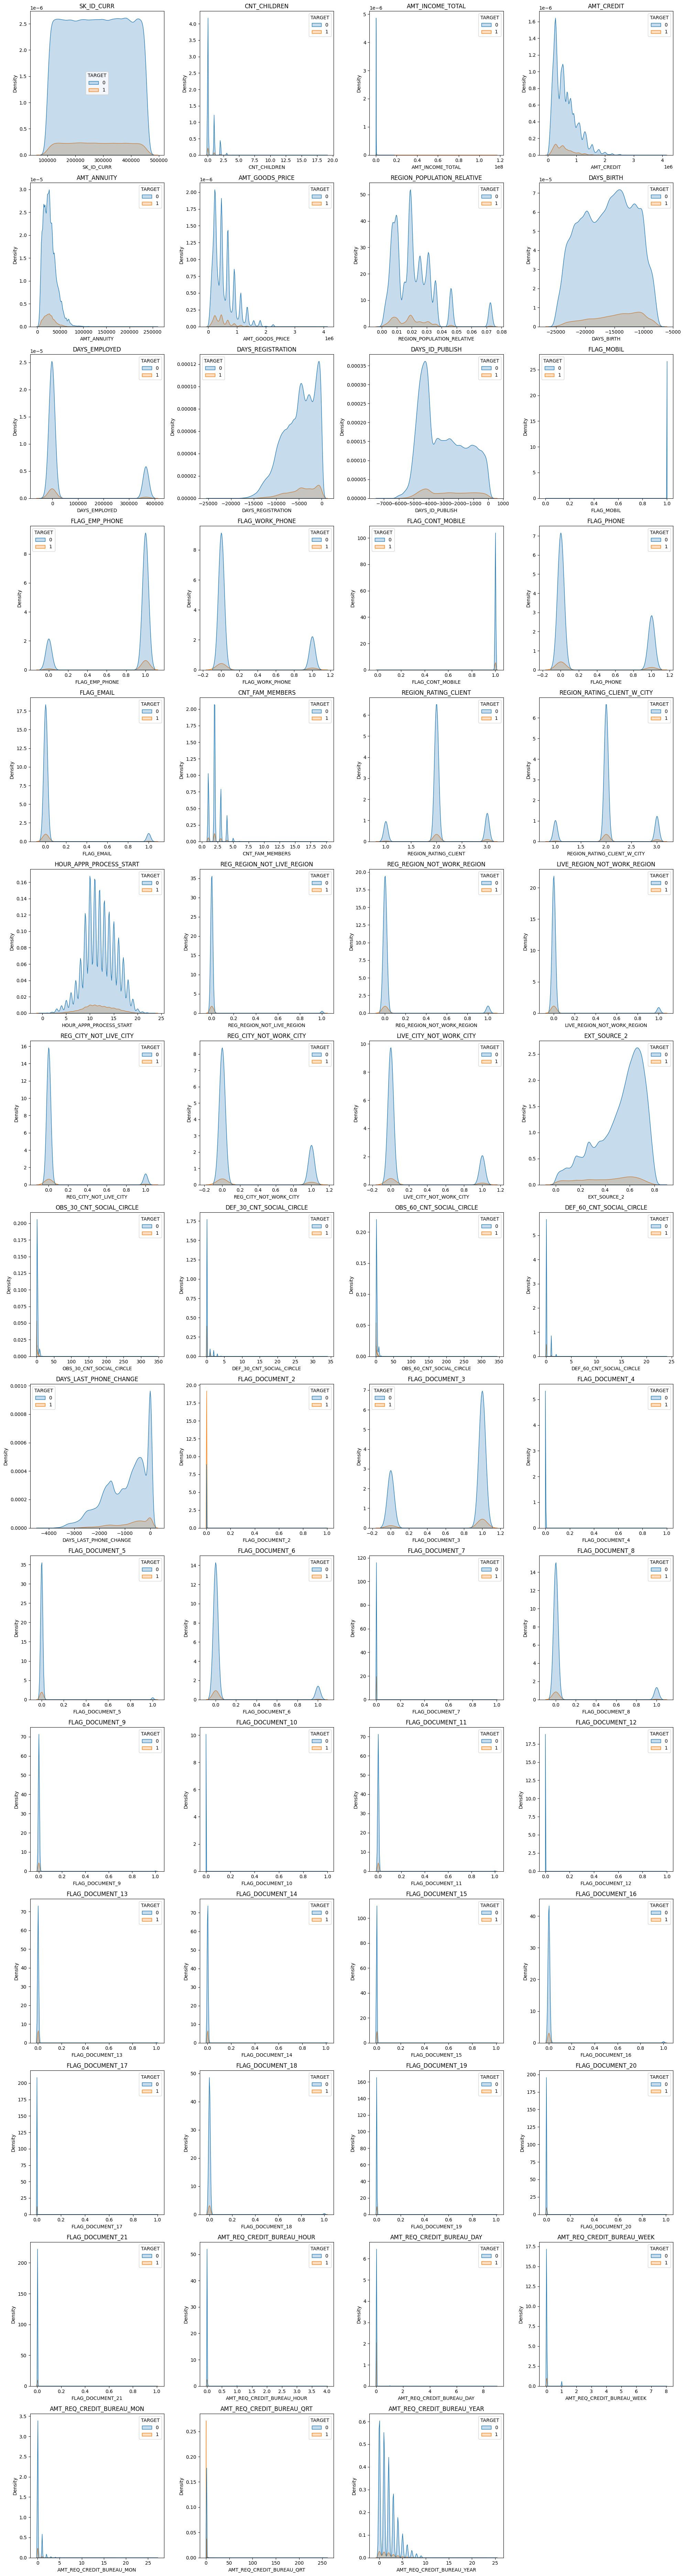

In [21]:
n_cols = 4
n_rows = (len(num) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, columns in enumerate(num):
    sns.kdeplot(data=EDA_y, x=columns, hue='TARGET', fill=True, ax=axes[i])
    axes[i].set_title(columns)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

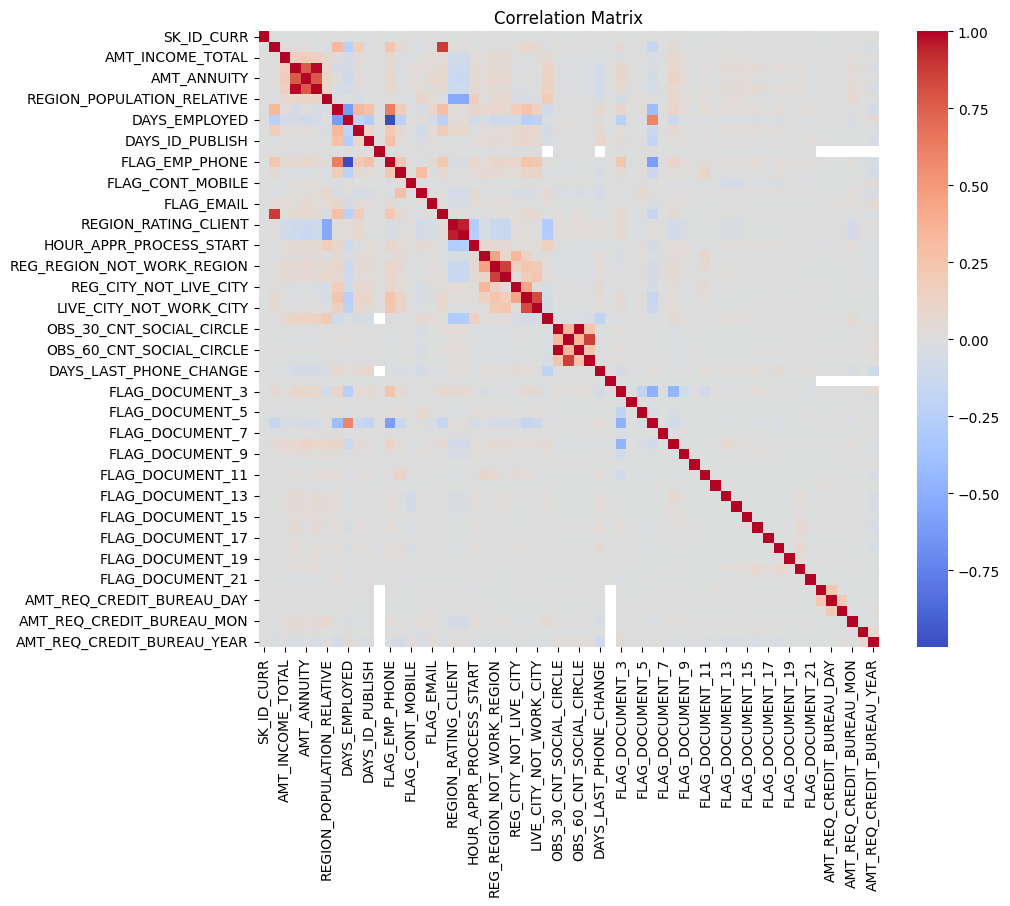

In [22]:
correlation_matrix = EDA[num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\1598253312.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=EDA[feature], ax=axes[i], order=top_10_categories, palette='viridis')
C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\1598253312.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=EDA[feature], ax=axes[i], order=top_10_categories, palette='viridis')
C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\1598253312.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=EDA[feature], ax=axes[i], order=top_10_categories, pa

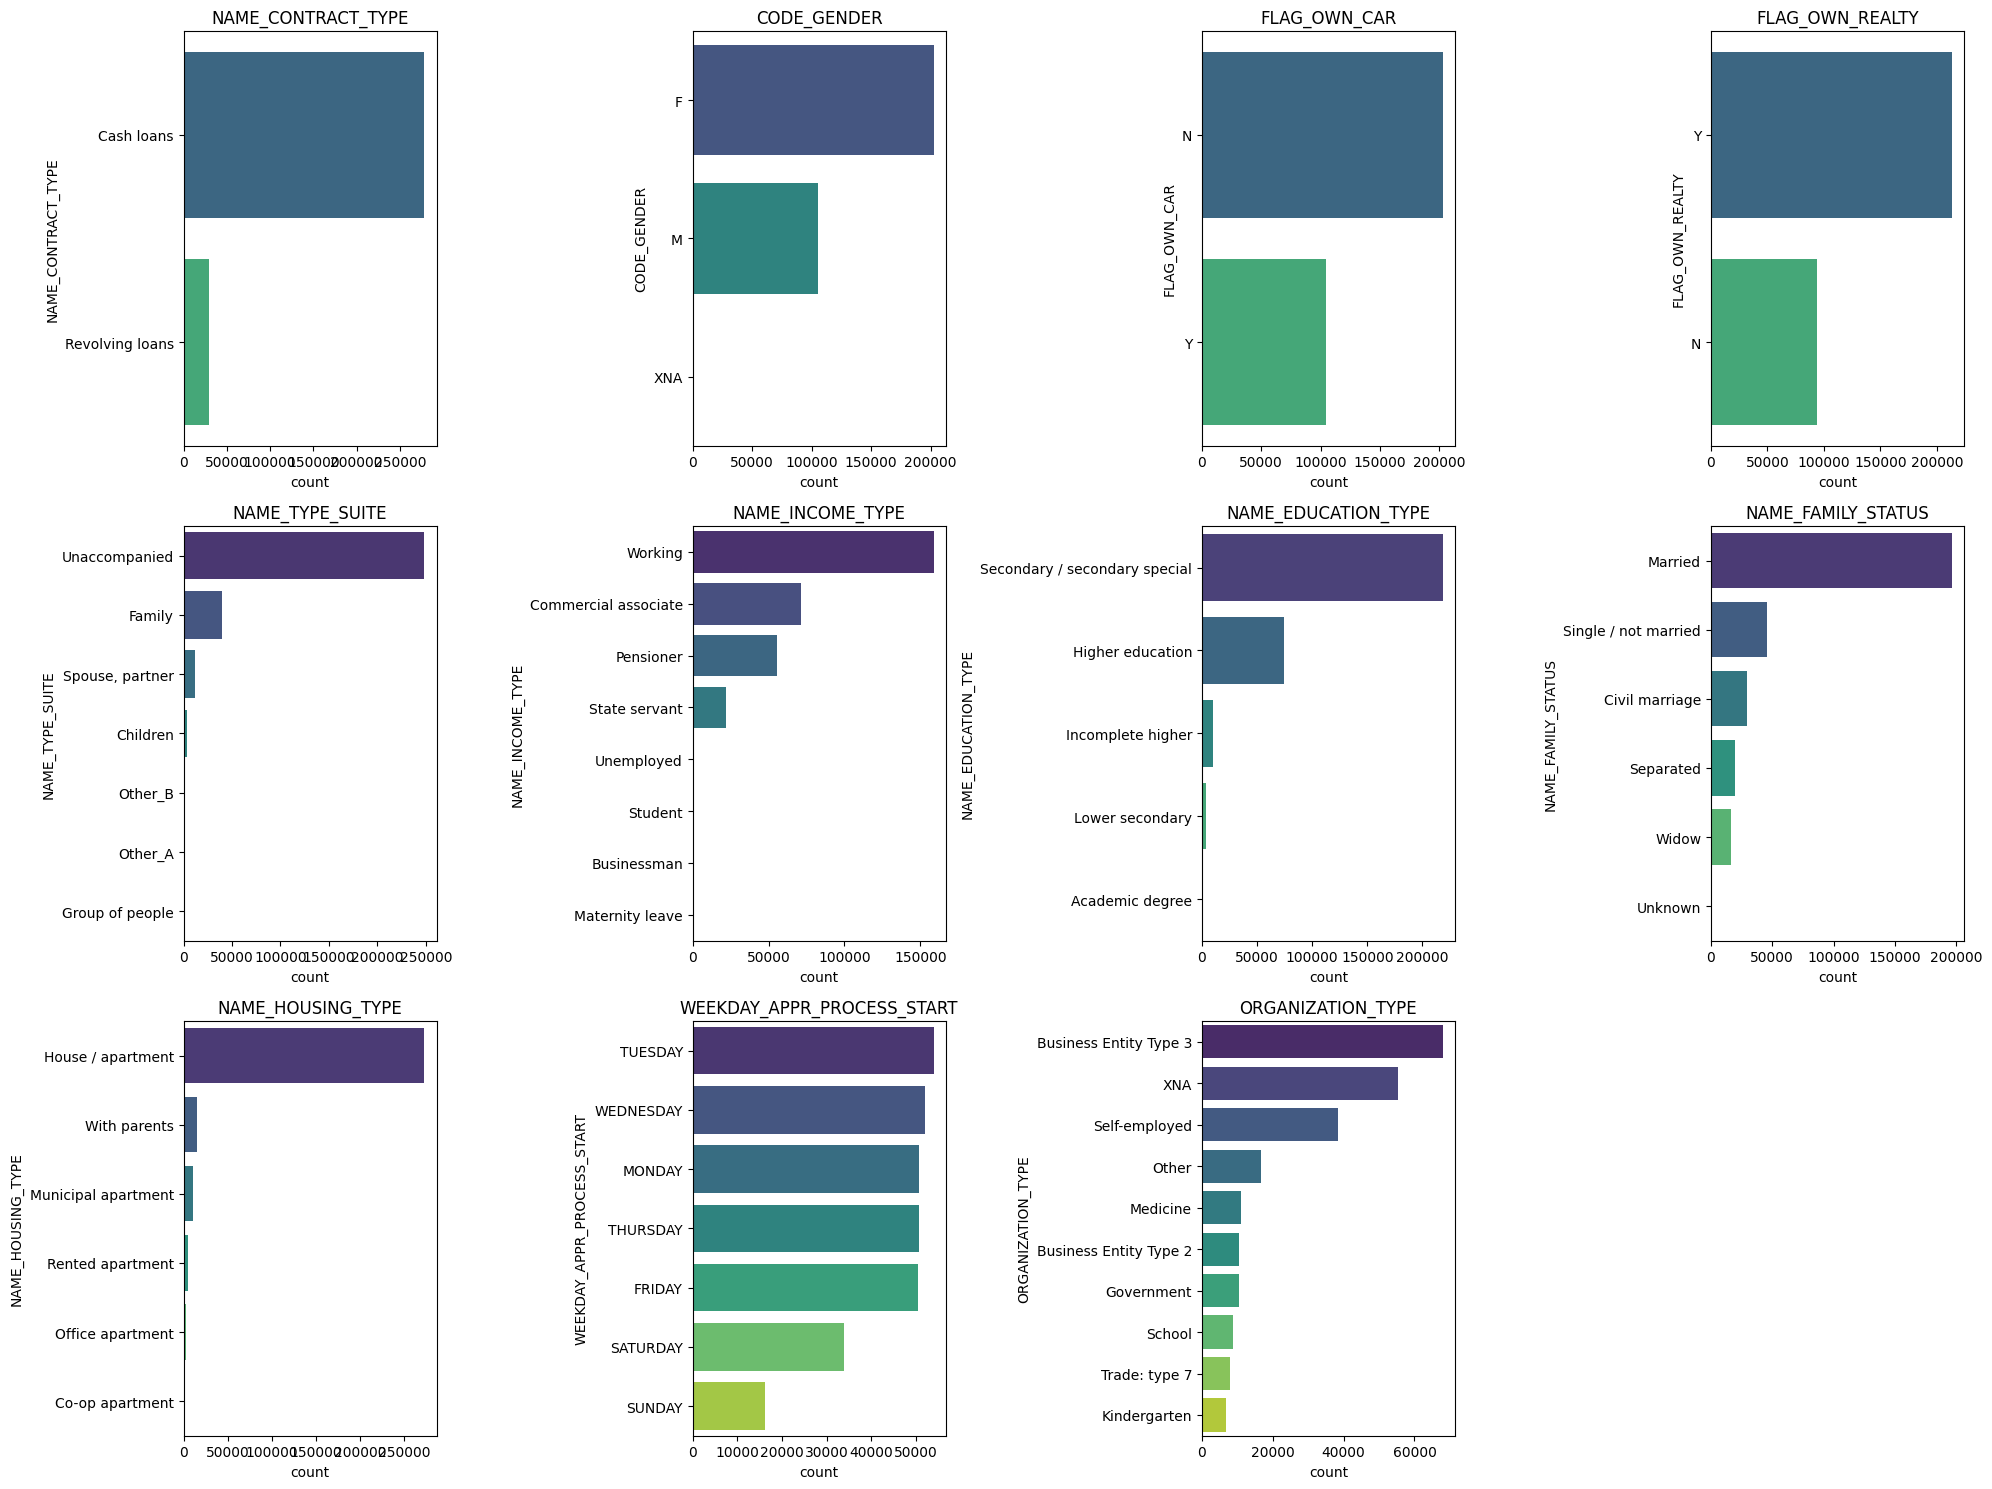

In [23]:
n_cols = 4
n_rows = (len(cat) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, feature in enumerate(cat):
    # Select top 10 categories
    top_10_categories = EDA[feature].value_counts().nlargest(10).index
    sns.countplot(y=EDA[feature], ax=axes[i], order=top_10_categories, palette='viridis')
    axes[i].set_title(feature)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [24]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 70 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   NAME_CONTRACT_TYPE           307511 non-null  object 
 2   CODE_GENDER                  307511 non-null  object 
 3   FLAG_OWN_CAR                 307511 non-null  object 
 4   FLAG_OWN_REALTY              307511 non-null  object 
 5   CNT_CHILDREN                 307511 non-null  int64  
 6   AMT_INCOME_TOTAL             307511 non-null  float64
 7   AMT_CREDIT                   307511 non-null  float64
 8   AMT_ANNUITY                  307499 non-null  float64
 9   AMT_GOODS_PRICE              307233 non-null  float64
 10  NAME_TYPE_SUITE              306219 non-null  object 
 11  NAME_INCOME_TYPE             307511 non-null  object 
 12  NAME_EDUCATION_TYPE          307511 non-null  object 
 13 

In [25]:
x_pre = x.copy()

In [26]:
x_pre = x_pre.drop(['SK_ID_CURR', 'WEEKDAY_APPR_PROCESS_START'], axis=1)
x_pre.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 68 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   NAME_CONTRACT_TYPE           307511 non-null  object 
 1   CODE_GENDER                  307511 non-null  object 
 2   FLAG_OWN_CAR                 307511 non-null  object 
 3   FLAG_OWN_REALTY              307511 non-null  object 
 4   CNT_CHILDREN                 307511 non-null  int64  
 5   AMT_INCOME_TOTAL             307511 non-null  float64
 6   AMT_CREDIT                   307511 non-null  float64
 7   AMT_ANNUITY                  307499 non-null  float64
 8   AMT_GOODS_PRICE              307233 non-null  float64
 9   NAME_TYPE_SUITE              306219 non-null  object 
 10  NAME_INCOME_TYPE             307511 non-null  object 
 11  NAME_EDUCATION_TYPE          307511 non-null  object 
 12  NAME_FAMILY_STATUS           307511 non-null  object 
 13 

In [27]:
x_pre.isnull().sum().sort_values(ascending=False)

AMT_REQ_CREDIT_BUREAU_MON      41519
AMT_REQ_CREDIT_BUREAU_WEEK     41519
AMT_REQ_CREDIT_BUREAU_DAY      41519
AMT_REQ_CREDIT_BUREAU_HOUR     41519
AMT_REQ_CREDIT_BUREAU_YEAR     41519
AMT_REQ_CREDIT_BUREAU_QRT      41519
NAME_TYPE_SUITE                 1292
OBS_30_CNT_SOCIAL_CIRCLE        1021
DEF_30_CNT_SOCIAL_CIRCLE        1021
OBS_60_CNT_SOCIAL_CIRCLE        1021
DEF_60_CNT_SOCIAL_CIRCLE        1021
EXT_SOURCE_2                     660
AMT_GOODS_PRICE                  278
AMT_ANNUITY                       12
CNT_FAM_MEMBERS                    2
DAYS_LAST_PHONE_CHANGE             1
FLAG_OWN_REALTY                    0
FLAG_OWN_CAR                       0
CODE_GENDER                        0
NAME_CONTRACT_TYPE                 0
FLAG_MOBIL                         0
FLAG_EMP_PHONE                     0
FLAG_CONT_MOBILE                   0
FLAG_WORK_PHONE                    0
AMT_CREDIT                         0
AMT_INCOME_TOTAL                   0
NAME_INCOME_TYPE                   0
C

In [28]:
x_pre.fillna(x_pre.median(numeric_only=True), inplace=True)

In [29]:
x_pre['NAME_TYPE_SUITE'].fillna('Unaccompanied', inplace=True)

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2409479371.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_pre['NAME_TYPE_SUITE'].fillna('Unaccompanied', inplace=True)


In [30]:
x_pre = x_pre[x_pre['NAME_FAMILY_STATUS'] != 'Unknown'].copy()

In [31]:
x_pre.isnull().sum()

NAME_CONTRACT_TYPE             0
CODE_GENDER                    0
FLAG_OWN_CAR                   0
FLAG_OWN_REALTY                0
CNT_CHILDREN                   0
AMT_INCOME_TOTAL               0
AMT_CREDIT                     0
AMT_ANNUITY                    0
AMT_GOODS_PRICE                0
NAME_TYPE_SUITE                0
NAME_INCOME_TYPE               0
NAME_EDUCATION_TYPE            0
NAME_FAMILY_STATUS             0
NAME_HOUSING_TYPE              0
REGION_POPULATION_RELATIVE     0
DAYS_BIRTH                     0
DAYS_EMPLOYED                  0
DAYS_REGISTRATION              0
DAYS_ID_PUBLISH                0
FLAG_MOBIL                     0
FLAG_EMP_PHONE                 0
FLAG_WORK_PHONE                0
FLAG_CONT_MOBILE               0
FLAG_PHONE                     0
FLAG_EMAIL                     0
CNT_FAM_MEMBERS                0
REGION_RATING_CLIENT           0
REGION_RATING_CLIENT_W_CITY    0
HOUR_APPR_PROCESS_START        0
REG_REGION_NOT_LIVE_REGION     0
REG_REGION

In [32]:
cols_map = {
    'DAYS_BIRTH': 'YEARS_BIRTH',
    'DAYS_EMPLOYED': 'YEARS_EMPLOYED',
    'DAYS_REGISTRATION': 'YEARS_REGISTRATION',
    'DAYS_ID_PUBLISH': 'YEARS_PUBLISH',
    'DAYS_LAST_PHONE_CHANGE': 'YEARS_LAST_PHONE_CHANGE'
}

for src, dest in cols_map.items():
    x_pre[dest] = (x_pre[src].abs() / 365).round().astype(int)


In [33]:
x_pre = x_pre.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE'], axis=1)

In [34]:
mappings = {
    'CODE_GENDER': {'F': 0, 'M': 1, 'XNA': 0},
    'FLAG_OWN_CAR': {'N': 0, 'Y': 1},
    'FLAG_OWN_REALTY': {'N': 0, 'Y': 1}
}

for col, mapping in mappings.items():
    x_pre[col] = x_pre[col].map(mapping)


In [35]:
x_feature_selc = pd.concat([x_pre, y], axis=1)
x_feature_selc_copy = x_feature_selc.copy()

In [36]:
cat_x = x_feature_selc.select_dtypes(include='object').columns
num_x = x_feature_selc.select_dtypes(include='number').columns

In [37]:
def woe(df_Apptrain, feature):
    # hitung jumlah & rata-rata target per kategori
    stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()
    stats.rename(columns={'count':'num_obs','mean':'good_rate'}, inplace=True)

    # jumlah good & bad
    stats['num_good'] = stats['good_rate'] * stats['num_obs']
    stats['num_bad']  = (1 - stats['good_rate']) * stats['num_obs']

    # proporsi good & bad, add epsilon to avoid division by zero
    epsilon = 1e-6
    stats['good_prop'] = (stats['num_good'] + epsilon) / (stats['num_good'].sum() + 2*epsilon)
    stats['bad_prop']  = (stats['num_bad'] + epsilon)  / (stats['num_bad'].sum() + 2*epsilon)

    # Weight of Evidence
    stats['woe'] = np.log(stats['good_prop'] / stats['bad_prop'])

    # Information Value (satu nilai total)
    iv = ((stats['good_prop'] - stats['bad_prop']) * stats['woe']).sum()
    stats['iv'] = iv

    return stats.sort_values('woe').reset_index(drop=True)

In [38]:
# build plot function
def plot_woe(df_Apptrain, xlabel_rotation=0):
    plt.figure(figsize=(8,4))
    sns.pointplot(x=df_Apptrain.columns[0], y='woe', data=df_Apptrain, marker='o', linestyle='--', color='blue')
    plt.title(str('Weight of Evidence by ' + df_Apptrain.columns[0]))
    plt.xticks(rotation = xlabel_rotation)

In [39]:
woe(x_feature_selc_copy, 'NAME_CONTRACT_TYPE')

,NAME_CONTRACT_TYPE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,Revolving loans,29277,0.054787,1604.0,27673.0,0.064612,0.097894,-0.415478,0.015033
1,Cash loans,278232,0.083459,23221.0,255011.0,0.935388,0.902106,0.036229,0.015033


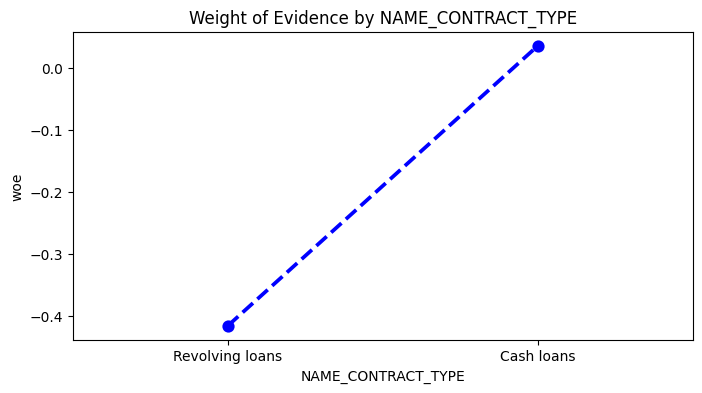

In [40]:
plot_woe(woe(x_feature_selc, 'NAME_CONTRACT_TYPE'))

In [41]:
woe(x_feature_selc_copy, 'NAME_TYPE_SUITE')

,NAME_TYPE_SUITE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,Children,3267,0.073768,241.0,3026.0,0.009708,0.010705,-0.097722,0.001402
1,Family,40149,0.074946,3009.0,37140.0,0.121208,0.131383,-0.080608,0.001402
2,"Spouse, partner",11370,0.078716,895.0,10475.0,0.036052,0.037056,-0.027445,0.001402
3,Unaccompanied,249816,0.081688,20407.0,229409.0,0.822034,0.811539,0.012850,0.001402
4,Group of people,271,0.084871,23.0,248.0,0.000926,0.000877,0.054544,0.001402
5,Other_A,866,0.087760,76.0,790.0,0.003061,0.002795,0.091179,0.001402
6,Other_B,1770,0.098305,174.0,1596.0,0.007009,0.005646,0.216278,0.001402


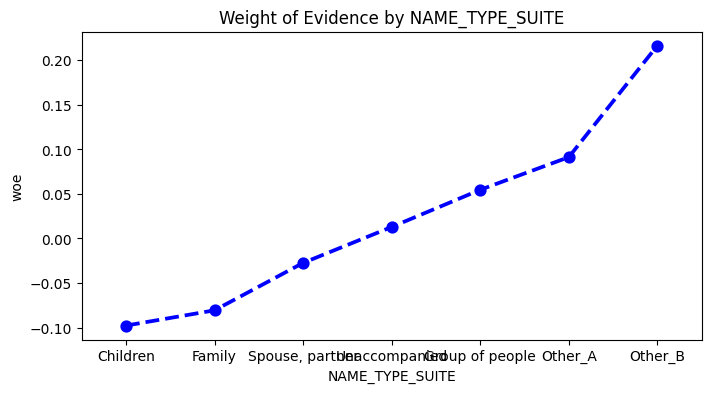

In [42]:
plot_woe(woe(x_feature_selc, 'NAME_TYPE_SUITE'))

In [43]:
woe(x_feature_selc_copy, 'NAME_INCOME_TYPE')

,NAME_INCOME_TYPE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,Student,18,0.000000,0.0,18.0,4.028197e-11,0.000064,-14.273404,0.059715
1,Businessman,10,0.000000,0.0,10.0,4.028197e-11,0.000035,-13.685617,0.059715
2,Pensioner,55362,0.053864,2982.0,52380.0,1.201208e-01,0.185295,-0.433452,0.059715
3,State servant,21703,0.057550,1249.0,20454.0,5.031219e-02,0.072356,-0.363357,0.059715
4,Commercial associate,71615,0.074845,5360.0,66255.0,2.159114e-01,0.234378,-0.082069,0.059715
5,Working,158774,0.095885,15224.0,143550.0,6.132528e-01,0.507811,0.188668,0.059715
6,Unemployed,22,0.363636,8.0,14.0,3.222558e-04,0.000050,1.872863,0.059715
7,Maternity leave,5,0.400000,2.0,3.0,8.056399e-05,0.000011,2.027014,0.059715


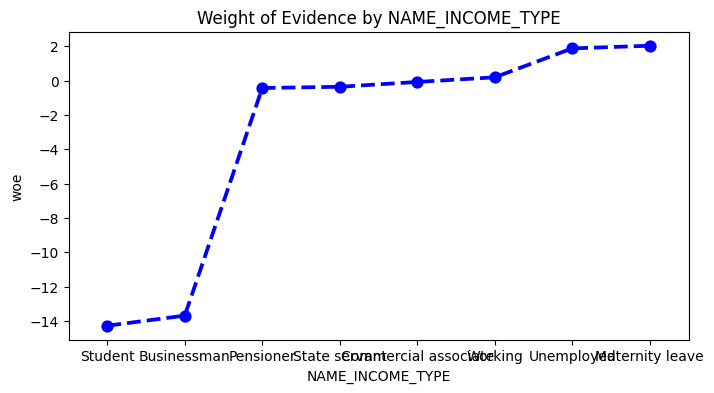

In [44]:
plot_woe(woe(x_feature_selc, 'NAME_INCOME_TYPE'))

In [45]:
woe(x_feature_selc_copy, 'NAME_EDUCATION_TYPE')

,NAME_EDUCATION_TYPE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,Academic degree,164,0.018293,3.0,161.0,0.000121,0.000570,-1.550313,0.050836
1,Higher education,74862,0.053552,4009.0,70853.0,0.161490,0.250644,-0.439587,0.050836
2,Incomplete higher,10277,0.084850,872.0,9405.0,0.035126,0.033270,0.054271,0.050836
3,Secondary / secondary special,218391,0.089399,19524.0,198867.0,0.786465,0.703496,0.111487,0.050836
4,Lower secondary,3815,0.109305,417.0,3398.0,0.016798,0.012020,0.334622,0.050836


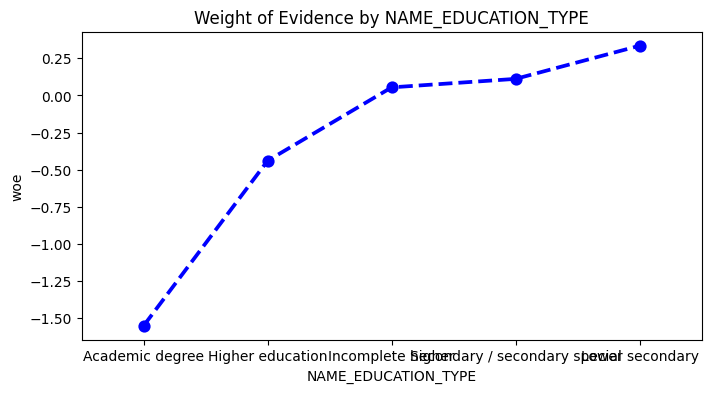

In [46]:
plot_woe(woe(x_feature_selc, 'NAME_EDUCATION_TYPE'))

In [47]:
woe(x_feature_selc_copy, 'NAME_FAMILY_STATUS')

,NAME_FAMILY_STATUS,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,Widow,16088,0.058242,937.0,15151.0,0.037744,0.053597,-0.350660,0.021698
1,Married,196432,0.075599,14850.0,181582.0,0.598187,0.642350,-0.071229,0.021698
2,Separated,19770,0.081942,1620.0,18150.0,0.065257,0.064206,0.016234,0.021698
3,Single / not married,45444,0.098077,4457.0,40987.0,0.179537,0.144992,0.213699,0.021698
4,Civil marriage,29775,0.099446,2961.0,26814.0,0.119275,0.094855,0.229081,0.021698


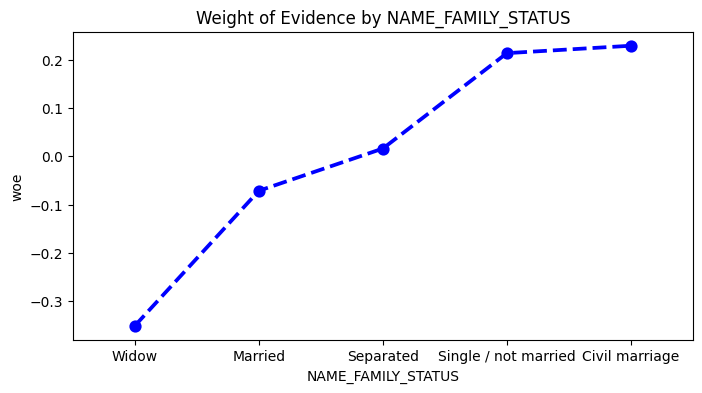

In [48]:
plot_woe(woe(x_feature_selc, 'NAME_FAMILY_STATUS'))

In [49]:
woe(x_feature_selc_copy, 'NAME_HOUSING_TYPE')

,NAME_HOUSING_TYPE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,Office apartment,2617,0.065724,172.0,2445.0,0.006928,0.008649,-0.221827,0.01573
1,House / apartment,272867,0.077957,21272.0,251595.0,0.856878,0.890022,-0.037951,0.01573
2,Co-op apartment,1122,0.079323,89.0,1033.0,0.003585,0.003654,-0.019108,0.01573
3,Municipal apartment,11182,0.085405,955.0,10227.0,0.038469,0.036178,0.061403,0.01573
4,With parents,14840,0.116981,1736.0,13104.0,0.069930,0.046356,0.411145,0.01573
5,Rented apartment,4881,0.123131,601.0,4280.0,0.024209,0.015141,0.469365,0.01573


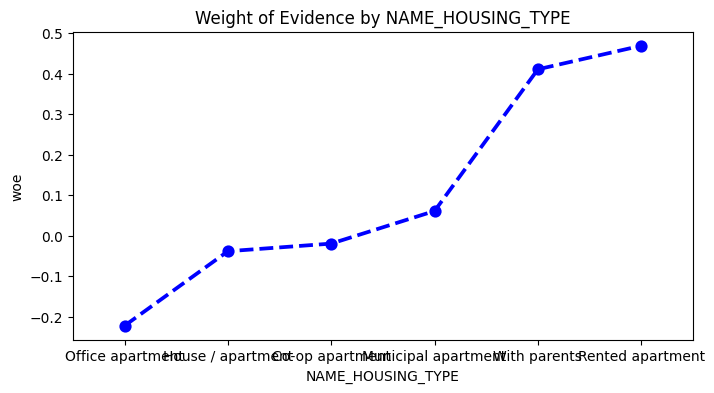

In [50]:
plot_woe(woe(x_feature_selc, 'NAME_HOUSING_TYPE'))

In [51]:
# build plot function
def plot_woe_10(df_Apptrain, xlabel_rotation=270):
    plt.figure(figsize=(8,4))
    sns.pointplot(x=df_Apptrain.columns[0], y='woe', data=df_Apptrain, marker='o', linestyle='--', color='blue')
    plt.title(str('Weight of Evidence by ' + df_Apptrain.columns[0]))
    plt.xticks(rotation = xlabel_rotation)

In [52]:
woe(x_feature_selc_copy, 'ORGANIZATION_TYPE')

,ORGANIZATION_TYPE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,Trade: type 4,64,0.031250,2.0,62.0,0.000081,0.000219,-1.001508,0.073366
1,Industry: type 12,369,0.037940,14.0,355.0,0.000564,0.001256,-0.800582,0.073366
2,Transport: type 1,201,0.044776,9.0,192.0,0.000363,0.000679,-0.627792,0.073366
3,Trade: type 6,631,0.045959,29.0,602.0,0.001168,0.002130,-0.600483,0.073366
4,Security Ministries,1974,0.048632,96.0,1878.0,0.003867,0.006643,-0.541136,0.073366
5,University,1327,0.048983,65.0,1262.0,0.002618,0.004464,-0.533587,0.073366
6,Police,2341,0.049979,117.0,2224.0,0.004713,0.007867,-0.512410,0.073366
7,Military,2634,0.051253,135.0,2499.0,0.005438,0.008840,-0.485893,0.073366
8,Bank,2507,0.051855,130.0,2377.0,0.005237,0.008409,-0.473582,0.073366
9,XNA,55374,0.053996,2990.0,52384.0,0.120443,0.185309,-0.430849,0.073366


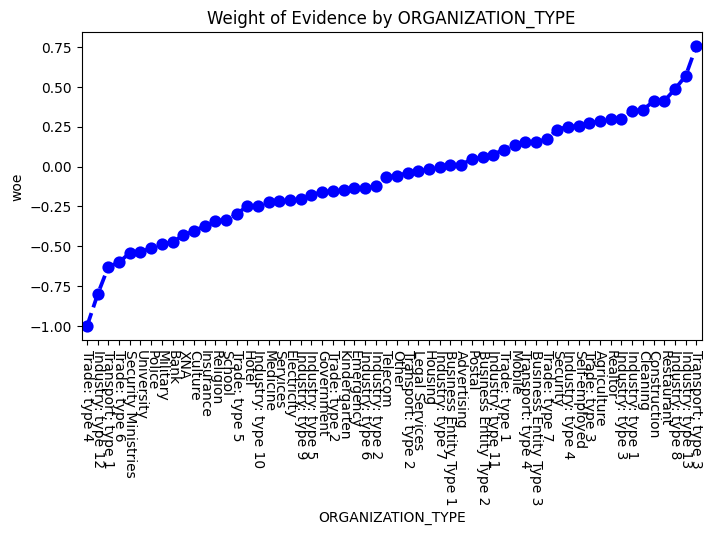

In [53]:
plot_woe_10(woe(x_feature_selc, 'ORGANIZATION_TYPE'))

In [54]:
def dist(feature):
    plt.figure(figsize=(4,2))
    sns.violinplot(x_feature_selc[feature], color='orange')
    print("Unique:", x_feature_selc[feature].nunique())
    print(x_feature_selc[feature].describe())


In [55]:
def plot_num_woe(woe_df, rot=0):
    plt.figure(figsize=(8,4))
    sns.pointplot(x=woe_df.columns[0], y='woe',
                  data=woe_df, color='orange')
    plt.title(f"Weight of Evidence by {woe_df.columns[0]}")
    plt.xticks(rotation=rot)
    plt.xlabel('')

In [56]:
woe(x_feature_selc, "CODE_GENDER")

,CODE_GENDER,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,202451,0.069992,14170.0,188281.0,0.570796,0.666048,-0.154330,0.038602
1,1.0,105058,0.101420,10655.0,94403.0,0.429204,0.333952,0.250935,0.038602


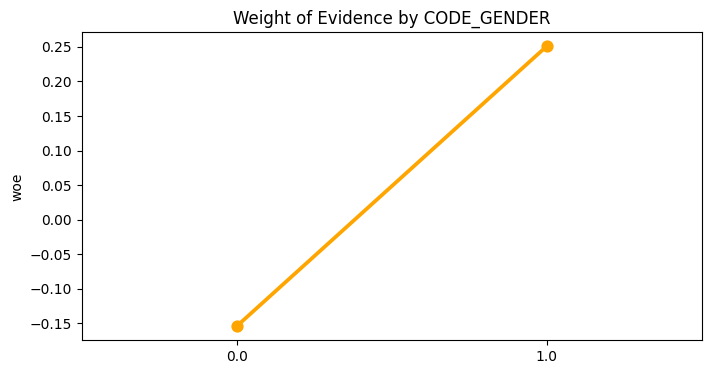

In [57]:
plot_num_woe(woe(x_feature_selc, "CODE_GENDER"))

In [58]:
woe(x_feature_selc, "FLAG_OWN_CAR")

,FLAG_OWN_CAR,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,1.0,104587,0.072437,7576.0,97011.0,0.305176,0.343178,-0.117361,0.006597
1,0.0,202922,0.085003,17249.0,185673.0,0.694824,0.656822,0.056246,0.006597


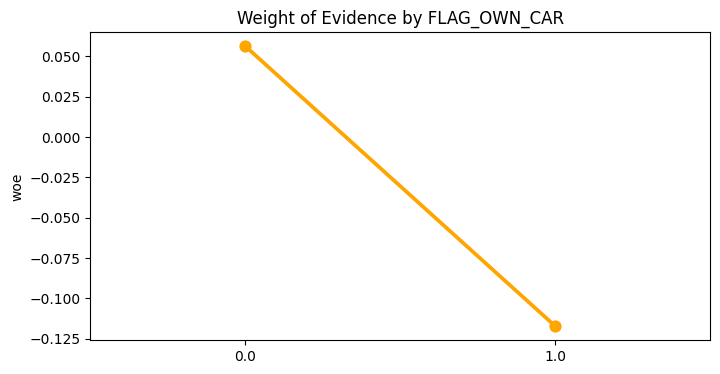

In [59]:
plot_num_woe(woe(x_feature_selc, "FLAG_OWN_CAR"))

In [60]:
woe(x_feature_selc, "FLAG_OWN_REALTY")

,FLAG_OWN_REALTY,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,1.0,213310,0.079617,16983.0,196327.0,0.684109,0.69451,-0.015090,0.000505
1,0.0,94199,0.083249,7842.0,86357.0,0.315891,0.30549,0.033482,0.000505


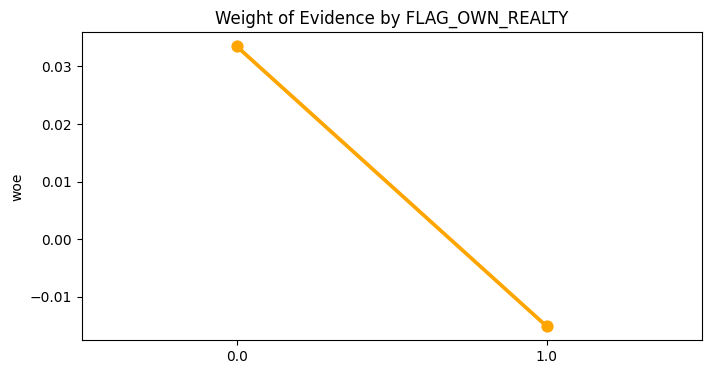

In [61]:
plot_num_woe(woe(x_feature_selc, "FLAG_OWN_REALTY"))

In [62]:
woe(x_feature_selc, "CNT_CHILDREN")

,CNT_CHILDREN,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,7.0,7,0.000000,0.0,7.0,4.028197e-11,2.476264e-05,-13.328942,0.00889
1,14.0,3,0.000000,0.0,3.0,4.028197e-11,1.061256e-05,-12.481645,0.00889
2,8.0,2,0.000000,0.0,2.0,4.028197e-11,7.075041e-06,-12.076180,0.00889
3,12.0,2,0.000000,0.0,2.0,4.028197e-11,7.075041e-06,-12.076180,0.00889
4,10.0,2,0.000000,0.0,2.0,4.028197e-11,7.075041e-06,-12.076180,0.00889
5,19.0,2,0.000000,0.0,2.0,4.028197e-11,7.075041e-06,-12.076180,0.00889
6,0.0,215369,0.077119,16609.0,198760.0,6.690433e-01,7.031173e-01,-0.049675,0.00889
7,5.0,84,0.083333,7.0,77.0,2.819739e-04,2.723890e-04,0.034583,0.00889
8,2.0,26749,0.087218,2333.0,24416.0,9.397784e-02,8.637206e-02,0.084395,0.00889
9,1.0,61119,0.089236,5454.0,55665.0,2.196979e-01,1.969160e-01,0.109476,0.00889


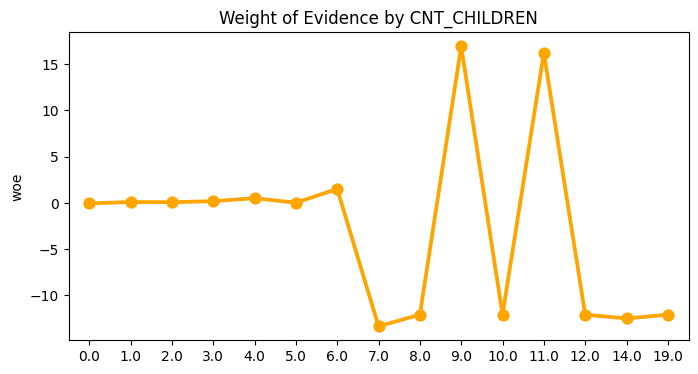

In [63]:
plot_num_woe(woe(x_feature_selc, "CNT_CHILDREN"))

Unique: 2548
count    3.075090e+05
mean     1.687969e+05
std      2.371234e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64


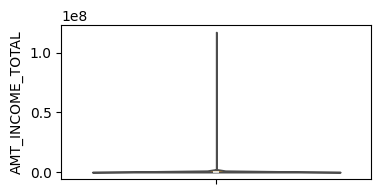

In [64]:
dist('AMT_INCOME_TOTAL')

In [65]:
bins = [
    (x_feature_selc['AMT_INCOME_TOTAL'] <= 100000),
    (x_feature_selc['AMT_INCOME_TOTAL'] <= 150000),
    (x_feature_selc['AMT_INCOME_TOTAL'] <= 200000),
    (x_feature_selc['AMT_INCOME_TOTAL'] <= 250000),
    (x_feature_selc['AMT_INCOME_TOTAL'] <= 300000)
]

labels = ['<100k','100k>','150k>','200k>','250k>']

x_feature_selc_copy['AMT_INCOME_TOTAL_FC'] = np.select(bins, labels, default='>300k')

print(x_feature_selc_copy['AMT_INCOME_TOTAL_FC'].value_counts())


AMT_INCOME_TOTAL_FC
100k>    91591
150k>    64307
<100k    63698
200k>    48136
>300k    22740
250k>    17039
Name: count, dtype: int64


In [66]:
woe(x_feature_selc_copy, 'AMT_INCOME_TOTAL_FC')

,AMT_INCOME_TOTAL_FC,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,>300k,22740,0.059499,1353.0,21387.0,0.054502,0.075656,-0.327973,0.010629
1,250k>,17039,0.070016,1193.0,15846.0,0.048056,0.056055,-0.153960,0.010629
2,200k>,48136,0.077447,3728.0,44408.0,0.150171,0.157093,-0.045062,0.010629
3,<100k,63698,0.082028,5225.0,58473.0,0.210473,0.206848,0.017375,0.010629
4,150k>,64307,0.084470,5432.0,58875.0,0.218812,0.208270,0.049376,0.010629
5,100k>,91591,0.086188,7894.0,83697.0,0.317986,0.296078,0.071385,0.010629


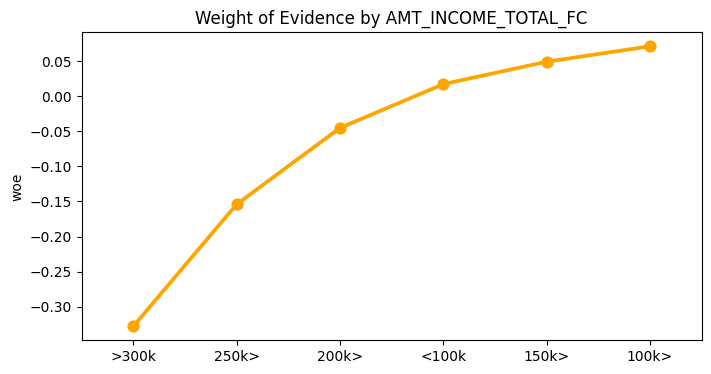

In [67]:
plot_num_woe(woe(x_feature_selc_copy, 'AMT_INCOME_TOTAL_FC'))

In [68]:
bins = [
    (x_feature_selc['AMT_CREDIT'] < 200000),
    (x_feature_selc['AMT_CREDIT'] <= 400000),
    (x_feature_selc['AMT_CREDIT'] <= 600000),
    (x_feature_selc['AMT_CREDIT'] <= 800000),
    (x_feature_selc['AMT_CREDIT'] <= 1000000)
]

labels = ['<200k','200k>','400k>','600k>','800k>']

x_feature_selc_copy['AMT_CREDIT_FC'] = np.select(bins, labels, default='>1m')

print(x_feature_selc_copy['AMT_CREDIT_FC'].value_counts())


AMT_CREDIT_FC
200k>    81151
400k>    66269
>1m      49987
600k>    43241
<200k    36144
800k>    30719
Name: count, dtype: int64


In [69]:
woe(x_feature_selc_copy, 'AMT_CREDIT_FC')

,AMT_CREDIT_FC,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,>1m,49987,0.058655,2932.0,47055.0,0.118107,0.166457,-0.343147,0.037051
1,<200k,36144,0.068891,2490.0,33654.0,0.100302,0.119051,-0.171364,0.037051
2,800k>,30719,0.071682,2202.0,28517.0,0.088701,0.100879,-0.128649,0.037051
3,600k>,43241,0.082399,3563.0,39678.0,0.143525,0.140361,0.022292,0.037051
4,200k>,81151,0.085569,6944.0,74207.0,0.279718,0.262507,0.063505,0.037051
5,400k>,66269,0.101013,6694.0,59575.0,0.269648,0.210746,0.246461,0.037051


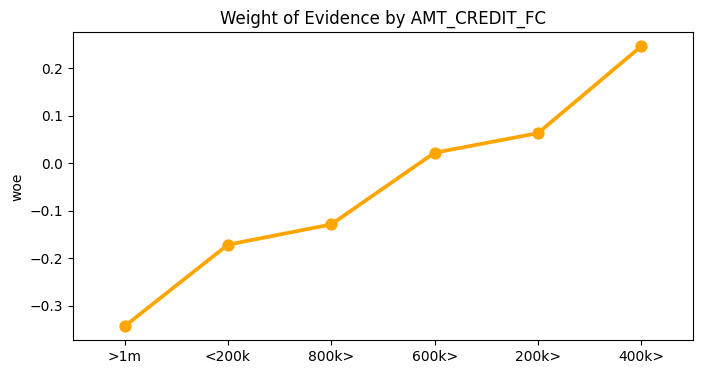

In [70]:
plot_num_woe(woe(x_feature_selc_copy, 'AMT_CREDIT_FC'))

Unique: 13672
count    307509.000000
mean      27108.459279
std       14493.502734
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64


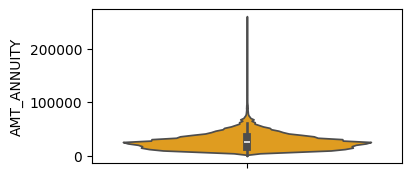

In [71]:
dist('AMT_ANNUITY')

In [72]:
bins = [0, 20000, 30000, 46000, float('inf')]
labels = ['<20k','20k>','30k>','46k>']

x_feature_selc_copy['AMT_ANNUITY_FC'] = pd.cut(x_feature_selc['AMT_ANNUITY'],
                                               bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['AMT_ANNUITY_FC'].value_counts())


AMT_ANNUITY_FC
<20k    106505
20k>     92477
30k>     77895
46k>     30632
Name: count, dtype: int64


In [73]:
woe(x_feature_selc_copy, 'AMT_ANNUITY_FC')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,AMT_ANNUITY_FC,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,46k>,30632,0.057848,1772.0,28860.0,0.071380,0.102093,-0.357869,0.01764
1,<20k,106505,0.075903,8084.0,98421.0,0.325639,0.348166,-0.066889,0.01764
2,30k>,77895,0.086154,6711.0,71184.0,0.270332,0.251815,0.070958,0.01764
3,20k>,92477,0.089298,8258.0,84219.0,0.332649,0.297926,0.110240,0.01764


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


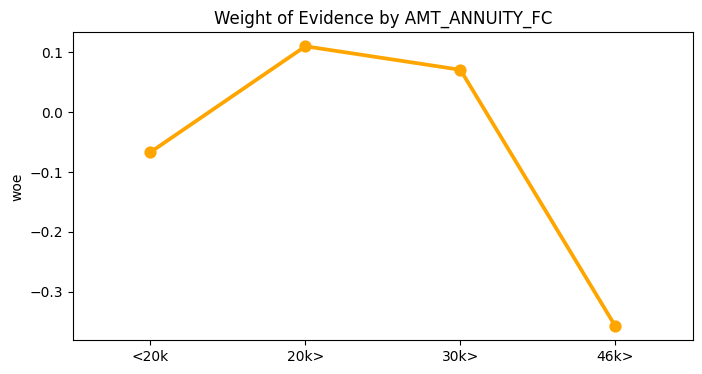

In [74]:
plot_num_woe(woe(x_feature_selc_copy, 'AMT_ANNUITY_FC'))

Unique: 1002
count    3.075090e+05
mean     5.383169e+05
std      3.692901e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64


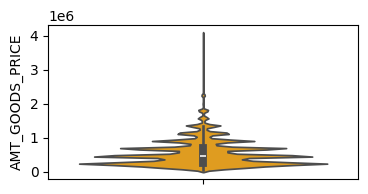

In [75]:
dist('AMT_GOODS_PRICE')

In [76]:
bins = [0, 300000, 600000, 900000, float('inf')]
labels = ['<300k','300k>','600k>','900k>']

x_feature_selc_copy['AMT_GOODS_PRICE_FC'] = pd.cut(x_feature_selc['AMT_GOODS_PRICE'],
                                                   bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['AMT_GOODS_PRICE_FC'].value_counts())


AMT_GOODS_PRICE_FC
<300k    104426
300k>     91585
600k>     69618
900k>     41880
Name: count, dtype: int64


In [77]:
woe(x_feature_selc_copy, 'AMT_GOODS_PRICE_FC')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,AMT_GOODS_PRICE_FC,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,900k>,41880,0.051122,2141.0,39739.0,0.086244,0.140577,-0.488582,0.045723
1,600k>,69618,0.074837,5210.0,64408.0,0.209869,0.227845,-0.082180,0.045723
2,<300k,104426,0.079894,8343.0,96083.0,0.336073,0.339895,-0.011311,0.045723
3,300k>,91585,0.099700,9131.0,82454.0,0.367815,0.291683,0.231913,0.045723


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


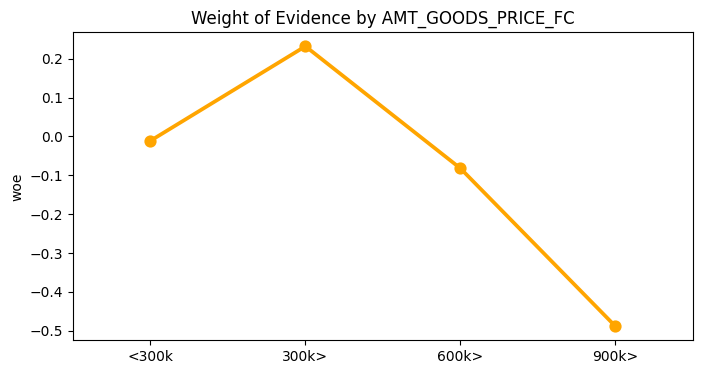

In [78]:
plot_num_woe(woe(x_feature_selc_copy, 'AMT_GOODS_PRICE_FC'))

Unique: 81
count    307509.000000
mean          0.020868
std           0.013831
min           0.000290
25%           0.010006
50%           0.018850
75%           0.028663
max           0.072508
Name: REGION_POPULATION_RELATIVE, dtype: float64


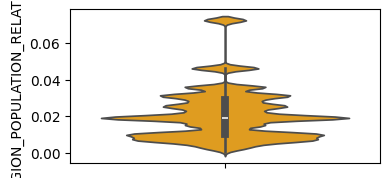

In [79]:
dist('REGION_POPULATION_RELATIVE')

In [80]:
x_feature_selc_copy['REGION_POPULATION_RELATIVE_FC'] = pd.cut(x_feature_selc['REGION_POPULATION_RELATIVE'],
                                                               bins=4, right=True)
x_feature_selc_copy['REGION_POPULATION_RELATIVE_FC'].value_counts()

REGION_POPULATION_RELATIVE_FC
(0.0183, 0.0364]      149313
(0.000218, 0.0183]    136342
(0.0364, 0.0545]       13442
(0.0545, 0.0725]        8412
Name: count, dtype: int64

In [81]:
woe(x_feature_selc_copy, 'REGION_POPULATION_RELATIVE_FC')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,REGION_POPULATION_RELATIVE_FC,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,"(0.0545, 0.0725]",8412,0.039705,334.0,8078.0,0.013454,0.028576,-0.753280,0.024104
1,"(0.0364, 0.0545]",13442,0.049323,663.0,12779.0,0.026707,0.045206,-0.526305,0.024104
2,"(0.0183, 0.0364]",149313,0.080241,11981.0,137332.0,0.482618,0.485815,-0.006601,0.024104
3,"(0.000218, 0.0183]",136342,0.086892,11847.0,124495.0,0.477221,0.440403,0.080288,0.024104


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


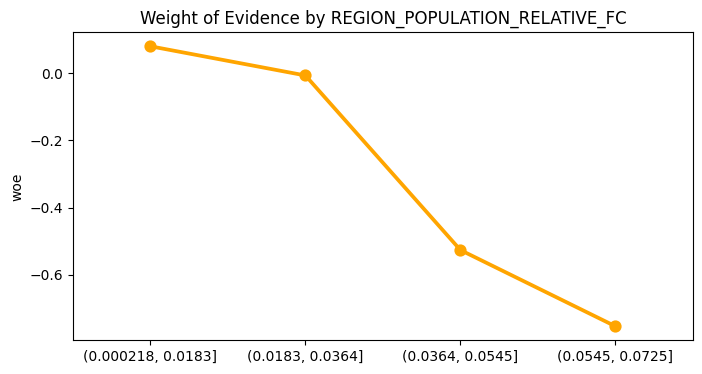

In [82]:
plot_num_woe(woe(x_feature_selc_copy, 'REGION_POPULATION_RELATIVE_FC'))

In [83]:
x_feature_selc['FLAG_MOBIL'].value_counts()

FLAG_MOBIL
1.0    307508
0.0         1
Name: count, dtype: int64

In [84]:
woe(x_feature_selc, 'FLAG_MOBIL')

,FLAG_MOBIL,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,1,0.00000,0.0,1.0,4.028197e-11,0.000004,-11.383033,0.00004
1,1.0,307508,0.08073,24825.0,282683.0,1.000000e+00,0.999996,0.000004,0.00004


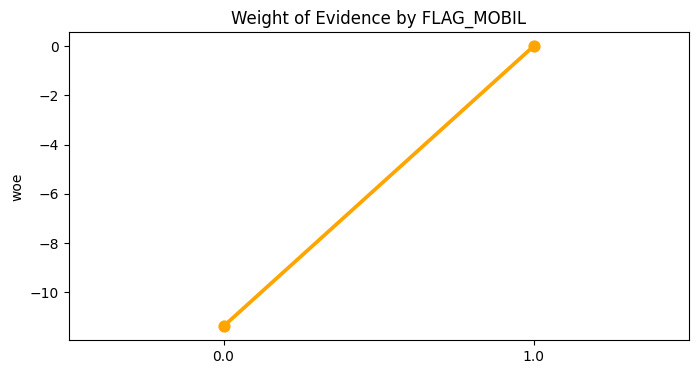

In [85]:
plot_num_woe(woe(x_feature_selc, 'FLAG_MOBIL'))

In [86]:
woe(x_feature_selc, 'FLAG_CONT_MOBILE')

,FLAG_CONT_MOBILE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,574,0.078397,45.0,529.0,0.001813,0.001871,-0.031847,0.000002
1,1.0,306935,0.080734,24780.0,282155.0,0.998187,0.998129,0.000059,0.000002


In [87]:
woe(x_feature_selc, 'FLAG_EMP_PHONE')

,FLAG_EMP_PHONE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,55386,0.054003,2991.0,52395.0,0.120483,0.185348,-0.430725,0.032908
1,1.0,252123,0.086601,21834.0,230289.0,0.879517,0.814652,0.076612,0.032908


In [88]:
woe(x_feature_selc, 'FLAG_EMAIL')

,FLAG_EMAIL,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,1.0,17442,0.078775,1374.0,16068.0,0.055347,0.056841,-0.026625,0.000042
1,0.0,290067,0.080847,23451.0,266616.0,0.944653,0.943159,0.001582,0.000042


Unique: 17
count    307509.000000
mean          2.152665
std           0.910682
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64


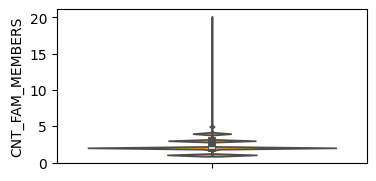

In [89]:
dist('CNT_FAM_MEMBERS')

In [90]:
bins = [0, 5, 10, 15, float('inf')]
labels = ['1-5','5-10','10-15','15-20']

x_feature_selc_copy['CNT_FAM_MEMBERS'] = pd.cut(x_feature_selc['CNT_FAM_MEMBERS'],
                                                   bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['CNT_FAM_MEMBERS'].value_counts())


CNT_FAM_MEMBERS
1-5      306980
5-10        518
10-15         7
15-20         4
Name: count, dtype: int64


In [91]:
woe(x_feature_selc_copy, 'CNT_FAM_MEMBERS')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,CNT_FAM_MEMBERS,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,15-20,4,0.000000,0.0,4.0,4.028197e-11,0.000014,-12.769327,0.0009
1,1-5,306980,0.080640,24755.0,282225.0,9.971803e-01,0.998376,-0.001199,0.0009
2,5-10,518,0.131274,68.0,450.0,2.739174e-03,0.001592,0.542739,0.0009
3,10-15,7,0.285714,2.0,5.0,8.056399e-05,0.000018,1.516188,0.0009


In [92]:
woe(x_feature_selc, 'REGION_RATING_CLIENT')

,REGION_RATING_CLIENT,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,1.0,32197,0.048203,1552.0,30645.0,0.062518,0.108407,-0.550447,0.048317
1,2.0,226982,0.078892,17907.0,209075.0,0.721329,0.739607,-0.025023,0.048317
2,3.0,48330,0.111028,5366.0,42964.0,0.216153,0.151986,0.352199,0.048317


In [93]:
woe(x_feature_selc, 'REGION_RATING_CLIENT_W_CITY')

,REGION_RATING_CLIENT_W_CITY,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,1.0,34167,0.048409,1654.0,32513.0,0.066626,0.115015,-0.545965,0.051201
1,2.0,229482,0.079178,18170.0,211312.0,0.731923,0.747520,-0.021085,0.051201
2,3.0,43860,0.114022,5001.0,38859.0,0.201450,0.137464,0.382177,0.051201


In [94]:
x_feature_selc_copy['HOUR_APPR_PROCESS_START'] = pd.cut(x_feature_selc['HOUR_APPR_PROCESS_START'],
                                                               bins=4, right=True)
x_feature_selc_copy['HOUR_APPR_PROCESS_START'].value_counts()

HOUR_APPR_PROCESS_START
(11.5, 17.25]     152996
(5.75, 11.5]      132435
(17.25, 23.0]      14689
(-0.023, 5.75]      7389
Name: count, dtype: int64

In [95]:
woe(x_feature_selc_copy, 'HOUR_APPR_PROCESS_START')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,HOUR_APPR_PROCESS_START,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,"(17.25, 23.0]",14689,0.069984,1028.0,13661.0,0.041410,0.048326,-0.154451,0.004069
1,"(11.5, 17.25]",152996,0.077616,11875.0,141121.0,0.478348,0.499218,-0.042704,0.004069
2,"(5.75, 11.5]",132435,0.084676,11214.0,121221.0,0.451722,0.428822,0.052026,0.004069
3,"(-0.023, 5.75]",7389,0.095818,708.0,6681.0,0.028520,0.023634,0.187900,0.004069


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


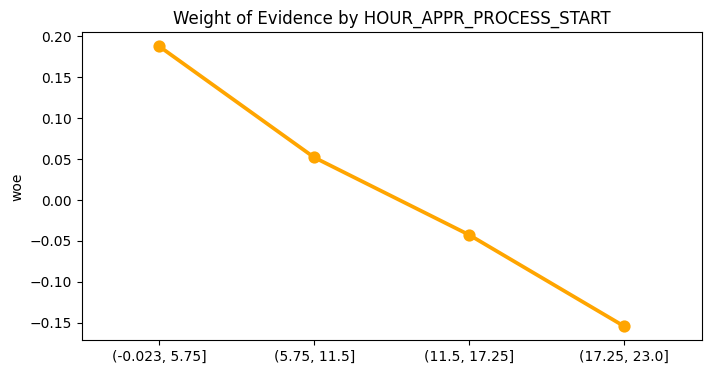

In [96]:
plot_num_woe(woe(x_feature_selc_copy, 'HOUR_APPR_PROCESS_START'))

In [97]:
woe(x_feature_selc, 'REG_REGION_NOT_LIVE_REGION')

,REG_REGION_NOT_LIVE_REGION,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,302852,0.080541,24392.0,278460.0,0.982558,0.985058,-0.002541,0.000393
1,1.0,4657,0.092978,433.0,4224.0,0.017442,0.014942,0.154678,0.000393


In [98]:
woe(x_feature_selc, 'REG_REGION_NOT_WORK_REGION')

,REG_REGION_NOT_WORK_REGION,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,291898,0.080292,23437.0,268461.0,0.944089,0.949686,-0.005911,0.000623
1,1.0,15611,0.088912,1388.0,14223.0,0.055911,0.050314,0.105482,0.000623


In [99]:
woe(x_feature_selc, 'REG_CITY_NOT_WORK_CITY')

,REG_CITY_NOT_WORK_CITY,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,236643,0.073127,17305.0,219338.0,0.69708,0.775912,-0.107140,0.032209
1,1.0,70866,0.106116,7520.0,63346.0,0.30292,0.224088,0.301433,0.032209


In [100]:
woe(x_feature_selc, 'LIVE_REGION_NOT_WORK_REGION')

,LIVE_REGION_NOT_WORK_REGION,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,295007,0.080571,23769.0,271238.0,0.957462,0.95951,-0.002136,0.000105
1,1.0,12502,0.084466,1056.0,11446.0,0.042538,0.04049,0.049326,0.000105


In [101]:
woe(x_feature_selc, 'LIVE_CITY_NOT_WORK_CITY')

,LIVE_CITY_NOT_WORK_CITY,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,252295,0.076585,19322.0,232973.0,0.778328,0.824146,-0.057200,0.01323
1,1.0,55214,0.099667,5503.0,49711.0,0.221672,0.175854,0.231546,0.01323


Unique: 119830
count    3.075090e+05
mean     5.145023e-01
std      1.908701e-01
min      8.173617e-08
25%      3.929737e-01
50%      5.659614e-01
75%      6.634218e-01
max      8.549997e-01
Name: EXT_SOURCE_2, dtype: float64


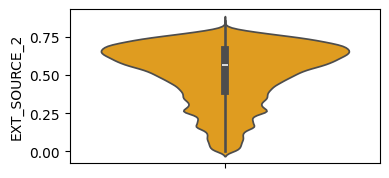

In [102]:
dist('EXT_SOURCE_2')

In [103]:
x_feature_selc_copy['EXT_SOURCE_2'] = pd.cut(x_feature_selc['EXT_SOURCE_2'],
                                               bins=4, right=True)
x_feature_selc_copy['EXT_SOURCE_2'].value_counts()

EXT_SOURCE_2
(0.427, 0.641]        123828
(0.641, 0.855]         95938
(0.214, 0.427]         57362
(-0.000855, 0.214]     30381
Name: count, dtype: int64

In [104]:
woe(x_feature_selc_copy, 'EXT_SOURCE_2')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,EXT_SOURCE_2,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,"(0.641, 0.855]",95938,0.040849,3919.0,92019.0,0.157865,0.325519,-0.723680,0.285138
1,"(0.427, 0.641]",123828,0.071938,8908.0,114920.0,0.358832,0.406532,-0.124808,0.285138
2,"(0.214, 0.427]",57362,0.111607,6402.0,50960.0,0.257885,0.180272,0.358048,0.285138
3,"(-0.000855, 0.214]",30381,0.184194,5596.0,24785.0,0.225418,0.087677,0.944292,0.285138


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


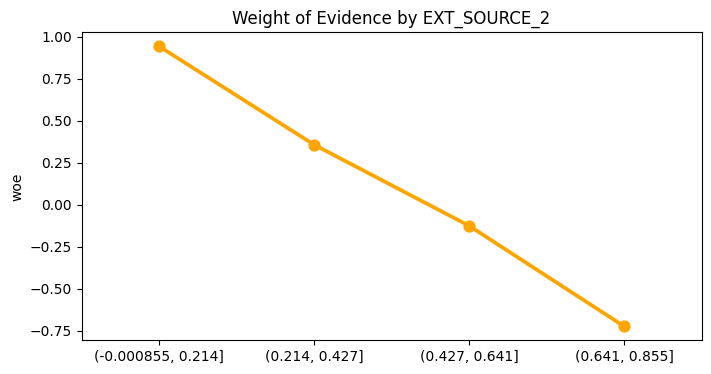

In [105]:
plot_num_woe(woe(x_feature_selc_copy, 'EXT_SOURCE_2'))

Unique: 33
count    307509.000000
mean          1.417519
std           2.398401
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         348.000000
Name: OBS_30_CNT_SOCIAL_CIRCLE, dtype: float64


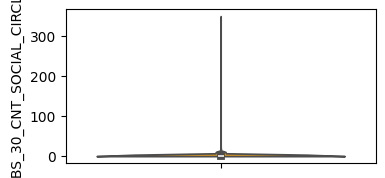

In [106]:
dist('OBS_30_CNT_SOCIAL_CIRCLE')

In [107]:
bins = [0, 1, 5, 10, 20, 30, float('inf')]
labels = ['0','>1','>5','>10','>20','>30']

x_feature_selc_copy['OBS_30_CNT_SOCIAL_CIRCLE'] = pd.cut(x_feature_selc['OBS_30_CNT_SOCIAL_CIRCLE'],
                                                   bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['OBS_30_CNT_SOCIAL_CIRCLE'].value_counts())


OBS_30_CNT_SOCIAL_CIRCLE
>1     73825
0      48782
>5     17189
>10     2680
>20      100
>30        2
Name: count, dtype: int64


In [108]:
woe(x_feature_selc_copy, 'OBS_30_CNT_SOCIAL_CIRCLE')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,OBS_30_CNT_SOCIAL_CIRCLE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,>30,2,0.000000,0.0,2.0,8.446659e-11,0.000015,-12.106854,0.001597
1,>20,100,0.070000,7.0,93.0,5.912662e-04,0.000711,-0.184885,0.001597
2,0,48782,0.079845,3895.0,44887.0,3.289974e-01,0.343333,-0.042651,0.001597
3,>1,73825,0.083684,6178.0,67647.0,5.218346e-01,0.517420,0.008495,0.001597
4,>5,17189,0.088021,1513.0,15676.0,1.277980e-01,0.119903,0.063767,0.001597
5,>10,2680,0.091791,246.0,2434.0,2.077878e-02,0.018617,0.109844,0.001597


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


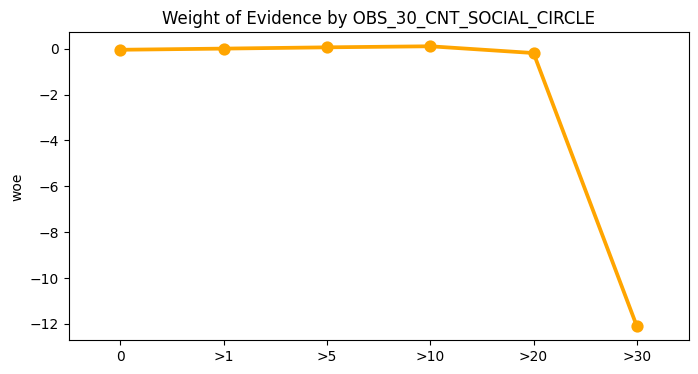

In [109]:
plot_num_woe(woe(x_feature_selc_copy, 'OBS_30_CNT_SOCIAL_CIRCLE'))


Unique: 10
count    307509.000000
mean          0.142945
std           0.446034
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          34.000000
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: float64


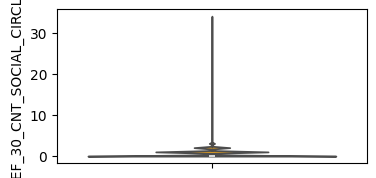

In [110]:
dist('DEF_30_CNT_SOCIAL_CIRCLE')

In [111]:
bins = [0, 1, 5, 7, float('inf')]
labels = ['0','>1','>5','>7']

x_feature_selc_copy['DEF_30_CNT_SOCIAL_CIRCLE'] = pd.cut(x_feature_selc['DEF_30_CNT_SOCIAL_CIRCLE'],
                                                   bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['DEF_30_CNT_SOCIAL_CIRCLE'].value_counts())


DEF_30_CNT_SOCIAL_CIRCLE
0     28328
>1     6824
>5       12
>7        2
Name: count, dtype: int64


In [112]:
woe(x_feature_selc_copy, 'DEF_30_CNT_SOCIAL_CIRCLE')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,DEF_30_CNT_SOCIAL_CIRCLE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,>7,2,0.000000,0.0,2.0,2.709293e-10,0.000064,-12.365362,0.006379
1,>5,12,0.083333,1.0,11.0,2.709296e-04,0.000349,-0.254598,0.006379
2,0,28328,0.101454,2874.0,25454.0,7.786508e-01,0.808705,-0.037872,0.006379
3,>1,6824,0.119578,816.0,6008.0,2.210783e-01,0.190882,0.146863,0.006379


In [113]:
bins = [0, 1, 5, 7, float('inf')]
labels = ['0','>1','>5','>7']

x_feature_selc_copy['OBS_60_CNT_SOCIAL_CIRCLE'] = pd.cut(x_feature_selc['OBS_60_CNT_SOCIAL_CIRCLE'],
                                                   bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['OBS_60_CNT_SOCIAL_CIRCLE'].value_counts())


OBS_60_CNT_SOCIAL_CIRCLE
>1    73389
0     48869
>5    10693
>7     8871
Name: count, dtype: int64


In [114]:
woe(x_feature_selc_copy, 'OBS_60_CNT_SOCIAL_CIRCLE')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,OBS_60_CNT_SOCIAL_CIRCLE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0,48869,0.079682,3894.0,44975.0,0.330897,0.345818,-0.044104,0.001389
1,>1,73389,0.083773,6148.0,67241.0,0.522434,0.517024,0.010409,0.001389
2,>7,8871,0.086800,770.0,8101.0,0.065432,0.062290,0.049213,0.001389
3,>5,10693,0.089404,956.0,9737.0,0.081237,0.074869,0.081635,0.001389


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


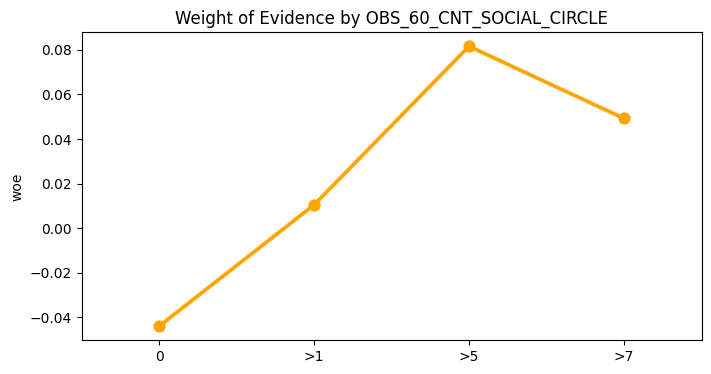

In [115]:
plot_num_woe(woe(x_feature_selc_copy, 'OBS_60_CNT_SOCIAL_CIRCLE'))

In [116]:
bins = [0, 1, 5, 7, float('inf')]
labels = ['0','>1','>5','>7']

x_feature_selc_copy['DEF_60_CNT_SOCIAL_CIRCLE'] = pd.cut(x_feature_selc['DEF_60_CNT_SOCIAL_CIRCLE'],
                                                   bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['DEF_60_CNT_SOCIAL_CIRCLE'].value_counts())


DEF_60_CNT_SOCIAL_CIRCLE
0     21841
>1     3923
>5        4
>7        1
Name: count, dtype: int64


In [117]:
woe(x_feature_selc_copy, 'DEF_60_CNT_SOCIAL_CIRCLE')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,DEF_60_CNT_SOCIAL_CIRCLE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,>5,4,0.000000,0.0,4.0,3.577818e-10,0.000174,-13.095274,0.008974
1,>7,1,0.000000,0.0,1.0,3.577818e-10,0.000044,-11.708981,0.008974
2,0,21841,0.105169,2297.0,19544.0,8.218247e-01,0.850701,-0.034533,0.008974
3,>1,3923,0.126944,498.0,3425.0,1.781753e-01,0.149082,0.178274,0.008974


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


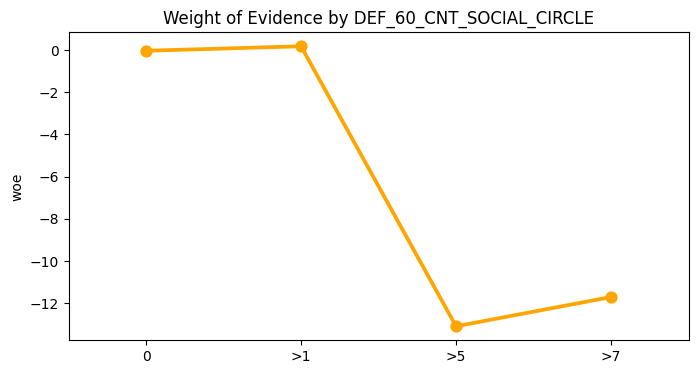

In [118]:
plot_num_woe(woe(x_feature_selc_copy, 'DEF_60_CNT_SOCIAL_CIRCLE'))

In [119]:
# daftar fitur yang ingin dihitung WOE-nya
features = ['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4',
            'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
            'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8',
            'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10',
            'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12',
            'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14',
            'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
            'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18',
            'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
            'FLAG_DOCUMENT_21']

# lakukan perulangan
for f in features:
    print(f"\nWOE untuk {f}:")
    display(woe(x_feature_selc, f))



WOE untuk FLAG_DOCUMENT_2:


,FLAG_DOCUMENT_2,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,307496,0.080720,24821.0,282675.0,0.999839,0.999968,-0.000129,0.00021
1,1.0,13,0.307692,4.0,9.0,0.000161,0.000032,1.621548,0.00021



WOE untuk FLAG_DOCUMENT_3:


,FLAG_DOCUMENT_3,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,89169,0.061826,5513.0,83656.0,0.222075,0.295935,-0.287126,0.028575
1,1.0,218340,0.088449,19312.0,199028.0,0.777925,0.704065,0.099760,0.028575



WOE untuk FLAG_DOCUMENT_4:


...

,FLAG_DOCUMENT_19,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,1.0,183,0.065574,12.0,171.0,0.000483,0.000605,-0.224278,0.000027
1,0.0,307326,0.080738,24813.0,282513.0,0.999517,0.999395,0.000122,0.000027



WOE untuk FLAG_DOCUMENT_20:


,FLAG_DOCUMENT_20,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,307353,0.080728,24812.0,282541.0,0.999476,0.999494,-0.000018,6.159159e-07
1,1.0,156,0.083333,13.0,143.0,0.000524,0.000506,0.034583,6.159159e-07



WOE untuk FLAG_DOCUMENT_21:


,FLAG_DOCUMENT_21,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,0.0,307406,0.080711,24811.0,282595.0,0.999436,0.999685,-0.000249,0.000145
1,1.0,103,0.135922,14.0,89.0,0.000564,0.000315,0.582899,0.000145


In [120]:
# daftar fitur yang ingin dihitung WOE-nya
features = ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
            'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
            'AMT_REQ_CREDIT_BUREAU_QRT']

# lakukan perulangan
for f in features:
    print(f"\nWOE untuk {f}:")
    display(woe(x_feature_selc, f))



WOE untuk AMT_REQ_CREDIT_BUREAU_HOUR:


,AMT_REQ_CREDIT_BUREAU_HOUR,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,3.0,9,0.000000,0.0,9.0,4.028197e-11,0.000032,-13.580257,0.000493
1,4.0,1,0.000000,0.0,1.0,4.028197e-11,0.000004,-11.383033,0.000493
2,1.0,1560,0.080128,125.0,1435.0,5.035247e-03,0.005076,-0.008128,0.000493
3,0.0,305883,0.080730,24694.0,281189.0,9.947231e-01,0.994711,0.000012,0.000493
4,2.0,56,0.107143,6.0,50.0,2.416919e-04,0.000177,0.312215,0.000493



WOE untuk AMT_REQ_CREDIT_BUREAU_DAY:


,AMT_REQ_CREDIT_BUREAU_DAY,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,5.0,9,0.000000,0.0,9.0,4.028197e-11,0.000032,-13.580257,0.001211
1,6.0,8,0.000000,0.0,8.0,4.028197e-11,0.000028,-13.462474,0.001211
2,9.0,2,0.000000,0.0,2.0,4.028197e-11,0.000007,-12.076180,0.001211
3,8.0,1,0.000000,0.0,1.0,4.028197e-11,0.000004,-11.383033,0.001211
4,3.0,45,0.044444,2.0,43.0,8.056399e-05,0.000152,-0.635574,0.001211
5,0.0,306020,0.080661,24684.0,281336.0,9.943202e-01,0.995231,-0.000916,0.001211
6,1.0,1292,0.096749,125.0,1167.0,5.035247e-03,0.004128,0.198601,0.001211
7,2.0,106,0.103774,11.0,95.0,4.431018e-04,0.000336,0.276497,0.001211
8,4.0,26,0.115385,3.0,23.0,1.208460e-04,0.000081,0.395597,0.001211



WOE untuk AMT_REQ_CREDIT_BUREAU_WEEK:


,AMT_REQ_CREDIT_BUREAU_WEEK,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,8.0,5,0.000000,0.0,5.0,4.028197e-11,0.000018,-12.992470,0.000446
1,7.0,2,0.000000,0.0,2.0,4.028197e-11,0.000007,-12.076180,0.000446
2,6.0,20,0.050000,1.0,19.0,4.028201e-05,0.000067,-0.511960,0.000446
3,3.0,58,0.068966,4.0,54.0,1.611279e-04,0.000191,-0.170211,0.000446
4,1.0,8208,0.077729,638.0,7570.0,2.569990e-02,0.026779,-0.041132,0.000446
5,0.0,298973,0.080800,24157.0,274816.0,9.730916e-01,0.972167,0.000951,0.000446
6,5.0,10,0.100000,1.0,9.0,4.028201e-05,0.000032,0.235255,0.000446
7,2.0,199,0.100503,20.0,179.0,8.056395e-04,0.000633,0.240825,0.000446
8,4.0,34,0.117647,4.0,30.0,1.611279e-04,0.000106,0.417576,0.000446



WOE untuk AMT_REQ_CREDIT_BUREAU_MON:


,AMT_REQ_CREDIT_BUREAU_MON,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,16.0,23,0.000000,0.0,23.0,4.028197e-11,0.000081,-14.518526,0.006052
1,18.0,6,0.000000,0.0,6.0,4.028197e-11,0.000021,-13.174792,0.006052
2,19.0,3,0.000000,0.0,3.0,4.028197e-11,0.000011,-12.481645,0.006052
3,22.0,1,0.000000,0.0,1.0,4.028197e-11,0.000004,-11.383033,0.006052
4,23.0,1,0.000000,0.0,1.0,4.028197e-11,0.000004,-11.383033,0.006052
5,27.0,1,0.000000,0.0,1.0,4.028197e-11,0.000004,-11.383033,0.006052
6,24.0,1,0.000000,0.0,1.0,4.028197e-11,0.000004,-11.383033,0.006052
7,12.0,77,0.012987,1.0,76.0,4.028201e-05,0.000269,-1.898254,0.006052
8,14.0,40,0.025000,1.0,39.0,4.028201e-05,0.000138,-1.231082,0.006052
9,15.0,35,0.028571,1.0,34.0,4.028201e-05,0.000120,-1.093881,0.006052



WOE untuk AMT_REQ_CREDIT_BUREAU_QRT:


,AMT_REQ_CREDIT_BUREAU_QRT,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,8.0,7,0.000000,0.0,7.0,4.028197e-11,2.476264e-05,-13.328942,0.007177
1,261.0,1,0.000000,0.0,1.0,4.028197e-11,3.537522e-06,-11.383033,0.007177
2,1.0,33862,0.065767,2227.0,31635.0,8.970796e-02,1.119094e-01,-0.221130,0.007177
3,3.0,1717,0.073384,126.0,1591.0,5.075529e-03,5.628193e-03,-0.103358,0.007177
4,0.0,256934,0.082500,21197.0,235737.0,8.538570e-01,8.339241e-01,0.023621,0.007177
5,2.0,14412,0.083472,1203.0,13209.0,4.845921e-02,4.672709e-02,0.036398,0.007177
6,5.0,64,0.093750,6.0,58.0,2.416919e-04,2.051761e-04,0.163795,0.007177
7,4.0,476,0.119748,57.0,419.0,2.296073e-03,1.482220e-03,0.437659,0.007177
8,7.0,7,0.142857,1.0,6.0,4.028201e-05,2.122512e-05,0.640720,0.007177
9,6.0,28,0.250000,7.0,21.0,2.819739e-04,7.428790e-05,1.333866,0.007177


Unique: 25
count    307509.000000
mean          1.778468
std           1.765528
min           0.000000
25%           1.000000
50%           1.000000
75%           3.000000
max          25.000000
Name: AMT_REQ_CREDIT_BUREAU_YEAR, dtype: float64


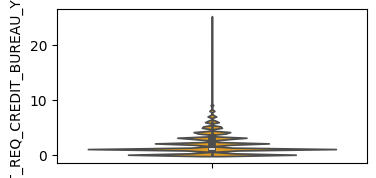

In [121]:
dist('AMT_REQ_CREDIT_BUREAU_YEAR')

In [122]:
bins = [0, 1, 2, 3, float('inf')]
labels = ['0','>1','>2','>3']

x_feature_selc_copy['AMT_REQ_CREDIT_BUREAU_YEAR'] = pd.cut(x_feature_selc['AMT_REQ_CREDIT_BUREAU_YEAR'],
                                                   bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts())


AMT_REQ_CREDIT_BUREAU_YEAR
0     104922
>1     50192
>3     46966
>2     33628
Name: count, dtype: int64


In [123]:
woe(x_feature_selc_copy, 'AMT_REQ_CREDIT_BUREAU_YEAR')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,AMT_REQ_CREDIT_BUREAU_YEAR,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,>2,33628,0.079577,2676.0,30952.0,0.135824,0.143292,-0.053528,0.000963
1,>1,50192,0.081049,4068.0,46124.0,0.206476,0.213531,-0.033596,0.000963
2,0,104922,0.085225,8942.0,95980.0,0.453863,0.444340,0.021205,0.000963
3,>3,46966,0.085509,4016.0,42950.0,0.203837,0.198837,0.024836,0.000963


Unique: 49
count    307509.000000
mean         43.938707
std          11.964062
min          21.000000
25%          34.000000
50%          43.000000
75%          54.000000
max          69.000000
Name: YEARS_BIRTH, dtype: float64


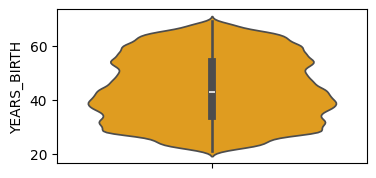

In [124]:
dist('YEARS_BIRTH')

In [125]:
bins = [21, 34, 44, 54, float('inf')]
labels = ['Remaja','Dewasa','Paruh Baya','Tua']

x_feature_selc_copy['YEARS_BIRTH'] = pd.cut(x_feature_selc['YEARS_BIRTH'],
                                                   bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['YEARS_BIRTH'].value_counts())


YEARS_BIRTH
Dewasa        84247
Remaja        79930
Tua           72593
Paruh Baya    70079
Name: count, dtype: int64


In [126]:
woe(x_feature_selc_copy, 'YEARS_BIRTH')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,YEARS_BIRTH,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,Tua,72593,0.052512,3812.0,68781.0,0.154008,0.243820,-0.459429,0.07976
1,Paruh Baya,70079,0.071748,5028.0,65051.0,0.203135,0.230598,-0.126805,0.07976
2,Dewasa,84247,0.085024,7163.0,77084.0,0.289391,0.273254,0.057378,0.07976
3,Remaja,79930,0.109458,8749.0,71181.0,0.353466,0.252328,0.337058,0.07976


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


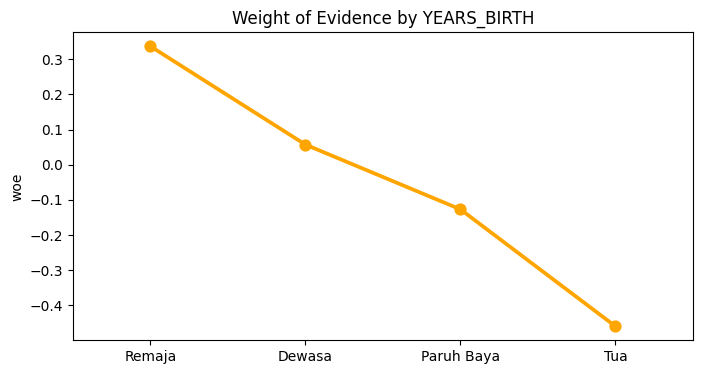

In [127]:
plot_num_woe(woe(x_feature_selc_copy, 'YEARS_BIRTH'))

Unique: 51
count    307509.000000
mean        185.609215
std         382.166843
min           0.000000
25%           3.000000
50%           6.000000
75%          16.000000
max        1001.000000
Name: YEARS_EMPLOYED, dtype: float64


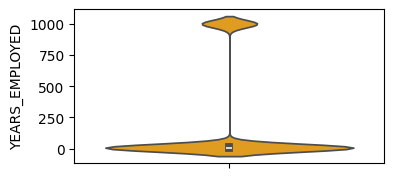

In [128]:
dist('YEARS_EMPLOYED')

In [129]:
bins = [0, 4, 16, 30, float('inf')]
labels = ['0-4','4-16','16-30','30++']

x_feature_selc_copy['YEARS_EMPLOYED'] = pd.cut(x_feature_selc['YEARS_EMPLOYED'],
                                                   bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['YEARS_EMPLOYED'].value_counts())


YEARS_EMPLOYED
0-4      115978
4-16     106936
30++      58125
16-30     16718
Name: count, dtype: int64


In [130]:
woe(x_feature_selc_copy, 'YEARS_EMPLOYED')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,YEARS_EMPLOYED,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,16-30,16718,0.046537,778.0,15940.0,0.032701,0.058182,-0.576164,0.099177
1,30++,58125,0.052886,3074.0,55051.0,0.129209,0.200941,-0.441584,0.099177
2,4-16,106936,0.070350,7523.0,99413.0,0.316212,0.362866,-0.137621,0.099177
3,0-4,115978,0.107055,12416.0,103562.0,0.521878,0.378010,0.322512,0.099177


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


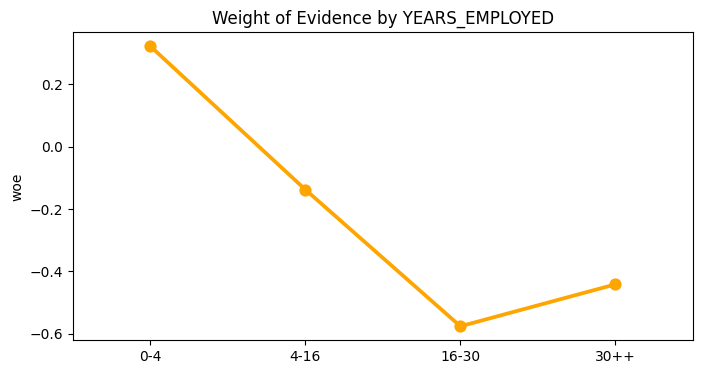

In [131]:
plot_num_woe(woe(x_feature_selc_copy, 'YEARS_EMPLOYED'))

In [132]:
x_feature_selc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307511 entries, 0 to 187348
Data columns (total 69 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   NAME_CONTRACT_TYPE           307509 non-null  object 
 1   CODE_GENDER                  307509 non-null  float64
 2   FLAG_OWN_CAR                 307509 non-null  float64
 3   FLAG_OWN_REALTY              307509 non-null  float64
 4   CNT_CHILDREN                 307509 non-null  float64
 5   AMT_INCOME_TOTAL             307509 non-null  float64
 6   AMT_CREDIT                   307509 non-null  float64
 7   AMT_ANNUITY                  307509 non-null  float64
 8   AMT_GOODS_PRICE              307509 non-null  float64
 9   NAME_TYPE_SUITE              307509 non-null  object 
 10  NAME_INCOME_TYPE             307509 non-null  object 
 11  NAME_EDUCATION_TYPE          307509 non-null  object 
 12  NAME_FAMILY_STATUS           307509 non-null  object 
 13  NAME

Unique: 66
count    307509.000000
mean         13.659486
std           9.659381
min           0.000000
25%           6.000000
50%          12.000000
75%          20.000000
max          68.000000
Name: YEARS_REGISTRATION, dtype: float64


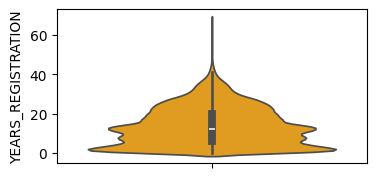

In [133]:
dist('YEARS_REGISTRATION')

In [134]:
bins = [0, 2, 4, 8, 16, 30, float('inf')]
labels = ['0-2','2-4','4-8','8-16', '16-30','30++']

x_feature_selc_copy['YEARS_REGISTRATION'] = pd.cut(x_feature_selc['YEARS_REGISTRATION'],
                                                   bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['YEARS_REGISTRATION'].value_counts())


YEARS_REGISTRATION
16-30    92203
8-16     87602
4-8      44051
0-2      31225
2-4      25895
30++     17526
Name: count, dtype: int64


In [135]:
woe(x_feature_selc_copy, 'YEARS_REGISTRATION')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,YEARS_REGISTRATION,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,30++,17526,0.054833,961.0,16565.0,0.040145,0.060332,-0.407356,0.02299
1,16-30,92203,0.069477,6406.0,85797.0,0.267608,0.312485,-0.155032,0.02299
2,8-16,87602,0.085934,7528.0,80074.0,0.314479,0.291641,0.075395,0.02299
3,4-8,44051,0.086105,3793.0,40258.0,0.158451,0.146625,0.077566,0.02299
4,2-4,25895,0.086812,2248.0,23647.0,0.093909,0.086126,0.086522,0.02299
5,0-2,31225,0.096141,3002.0,28223.0,0.125407,0.102792,0.198859,0.02299


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


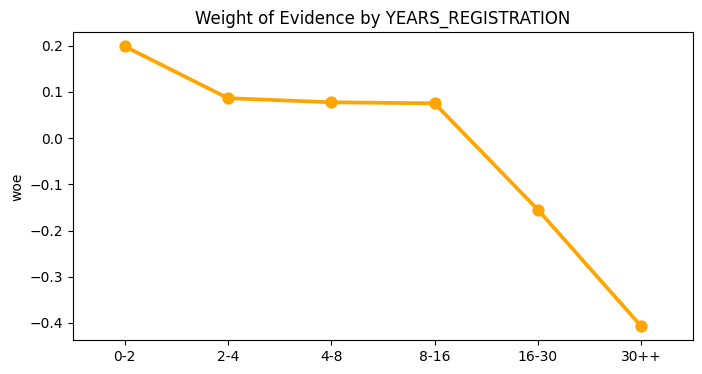

In [136]:
plot_num_woe(woe(x_feature_selc_copy, 'YEARS_REGISTRATION'))

Unique: 20
count    307509.000000
mean          8.198576
std           4.151521
min           0.000000
25%           5.000000
50%           9.000000
75%          12.000000
max          20.000000
Name: YEARS_PUBLISH, dtype: float64


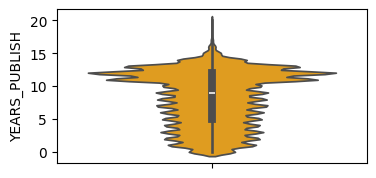

In [137]:
dist('YEARS_PUBLISH')

In [138]:
bins = [0, 4, 8, 12, float('inf')]
labels = ['0-4','4-8','8-12','12++']

x_feature_selc_copy['YEARS_PUBLISH'] = pd.cut(x_feature_selc['YEARS_PUBLISH'],
                                                   bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['YEARS_PUBLISH'].value_counts())


YEARS_PUBLISH
8-12    114694
4-8      72672
0-4      65577
12++     46705
Name: count, dtype: int64


In [139]:
woe(x_feature_selc_copy, 'YEARS_PUBLISH')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,YEARS_PUBLISH,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,12++,46705,0.060251,2814.0,43891.0,0.117113,0.159245,-0.307299,0.033523
1,8-12,114694,0.072192,8280.0,106414.0,0.344598,0.386090,-0.113691,0.033523
2,4-8,72672,0.088782,6452.0,66220.0,0.268520,0.240258,0.111211,0.033523
3,0-4,65577,0.098846,6482.0,59095.0,0.269769,0.214408,0.229686,0.033523


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


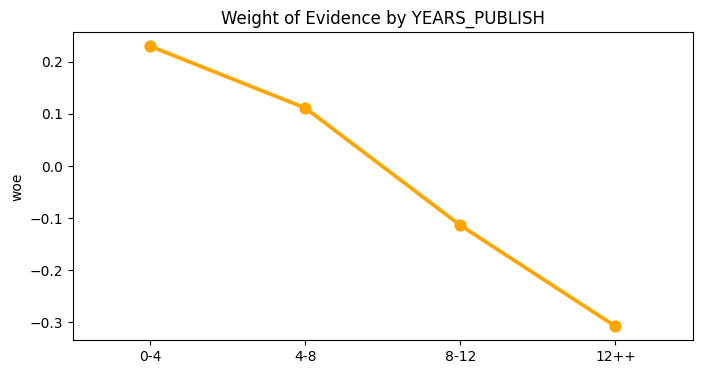

In [140]:
plot_num_woe(woe(x_feature_selc_copy, 'YEARS_PUBLISH'))

Unique: 13
count    307509.000000
mean          2.632873
std           2.281348
min           0.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          12.000000
Name: YEARS_LAST_PHONE_CHANGE, dtype: float64


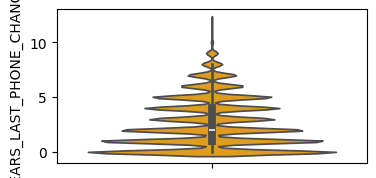

In [141]:
dist('YEARS_LAST_PHONE_CHANGE')

In [142]:
bins = [0, 4, 8, float('inf')]
labels = ['0-4','4-8','8-12']

x_feature_selc_copy['YEARS_LAST_PHONE_CHANGE'] = pd.cut(x_feature_selc['YEARS_LAST_PHONE_CHANGE'],
                                                   bins=bins, labels=labels, right=True)

print(x_feature_selc_copy['YEARS_LAST_PHONE_CHANGE'].value_counts())


YEARS_LAST_PHONE_CHANGE
0-4     174136
4-8      65631
8-12      3566
Name: count, dtype: int64


In [143]:
woe(x_feature_selc_copy, 'YEARS_LAST_PHONE_CHANGE')

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


,YEARS_LAST_PHONE_CHANGE,num_obs,good_rate,num_good,num_bad,good_prop,bad_prop,woe,iv
0,8-12,3566,0.043746,156.0,3410.0,0.008311,0.015185,-0.602715,0.029495
1,4-8,65631,0.059682,3917.0,61714.0,0.208684,0.274818,-0.275288,0.029495
2,0-4,174136,0.084400,14697.0,159439.0,0.783005,0.709997,0.097878,0.029495


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\2945202709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_Apptrain.groupby(feature)['TARGET'].agg(['count','mean']).reset_index()


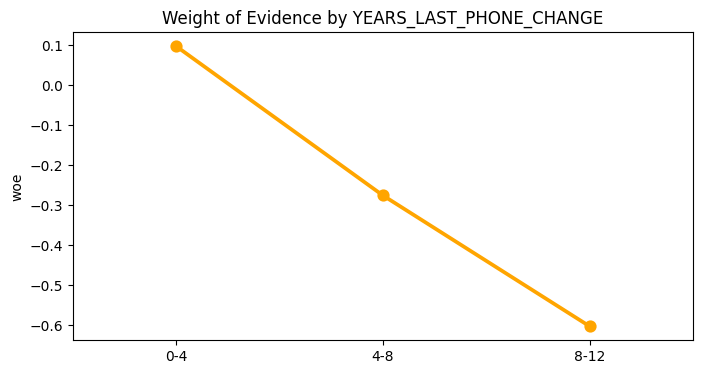

In [144]:
plot_num_woe(woe(x_feature_selc_copy, 'YEARS_LAST_PHONE_CHANGE'))

In [145]:
list_features = ['CODE_GENDER', 'FLAG_OWN_CAR', 'AMT_INCOME_TOTAL', 'AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE','REGION_POPULATION_RELATIVE',
                 'CNT_FAM_MEMBERS', 'HOUR_APPR_PROCESS_START', 'EXT_SOURCE_2','OBS_30_CNT_SOCIAL_CIRCLE',
                 'OBS_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'YEARS_BIRTH', 'YEARS_EMPLOYED', 'YEARS_REGISTRATION',
                 'YEARS_PUBLISH', 'YEARS_LAST_PHONE_CHANGE']

len(list_features)

18

In [146]:
x_feature_selc[list_features].nunique()

CODE_GENDER                        2
FLAG_OWN_CAR                       2
AMT_INCOME_TOTAL                2548
AMT_CREDIT                      5603
AMT_ANNUITY                    13672
AMT_GOODS_PRICE                 1002
REGION_POPULATION_RELATIVE        81
CNT_FAM_MEMBERS                   17
HOUR_APPR_PROCESS_START           24
EXT_SOURCE_2                  119830
OBS_30_CNT_SOCIAL_CIRCLE          33
OBS_60_CNT_SOCIAL_CIRCLE          33
AMT_REQ_CREDIT_BUREAU_YEAR        25
YEARS_BIRTH                       49
YEARS_EMPLOYED                    51
YEARS_REGISTRATION                66
YEARS_PUBLISH                     20
YEARS_LAST_PHONE_CHANGE           13
dtype: int64

In [147]:
df_encod = x_feature_selc[list_features].copy()
df_target = x_feature_selc['TARGET']

In [148]:
# definisi binning untuk tiap variabel
binning_rules = {
    'AMT_INCOME_TOTAL': {
        'bins': [0, 100000, 150000, 200000, 250000, 300000, np.inf],
        'labels': ['<100k','100k>','150k>','200k>','250k>','>_300k']
    },
    'AMT_CREDIT': {
        'bins': [0, 200000, 400000, 600000, 800000, 1000000, np.inf],
        'labels': ['<200k','200k>','400k>','600k>','800k>','>1m']
    },
    'AMT_ANNUITY': {
        'bins': [0, 20000, 30000, 46000, np.inf],
        'labels': ['<20k','20k>','30k>','46k>']
    },
    'AMT_GOODS_PRICE': {
        'bins': [0, 300000, 600000, 900000, np.inf],
        'labels': ['<300k','300k>','600k>','900k>']
    },
    'REGION_POPULATION_RELATIVE': {
        'bins': [0, 0.0183, 0.0364, 0.0545, 0.0725, np.inf],
        'labels': ['1','2','3','4','>4']
    },
    'CNT_FAM_MEMBERS': {
        'bins': [0, 5, 10, 15, np.inf],
        'labels': ['1-5','5-10','10-15','15-20']
    },
    'HOUR_APPR_PROCESS_START': {
        'bins': [0, 6, 12, 18, np.inf],
        'labels': ['0_6','6_12','12_18','>18']
    },
    'EXT_SOURCE_2': {
        'bins': [0, 0.214, 0.427, 0.641, np.inf],
        'labels': ['2','2_4','4_6','>6']
    },
    'OBS_30_CNT_SOCIAL_CIRCLE': {
        'bins': [0, 1, 5, 10, 20, 30, np.inf],
        'labels': ['0','>1','>5','>10','>20','>30']
    },
    'OBS_60_CNT_SOCIAL_CIRCLE': {
        'bins': [0, 1, 5, 7, np.inf],
        'labels': ['0','>1','>5','>7']
    },
    'AMT_REQ_CREDIT_BUREAU_YEAR': {
        'bins': [0, 1, 2, 3, np.inf],
        'labels': ['0','>1','>2','>3']
    },
    'YEARS_BIRTH': {
        'bins': [0, 30, 40, 50, 60, np.inf],
        'labels': ['>20','>30','>40','>50','>60']
    },
    'YEARS_EMPLOYED': {
        'bins': [0, 4, 16, 30, np.inf],
        'labels': ['0-4','4-16','16-30','30++']
    },
    'YEARS_REGISTRATION': {
        'bins': [0, 2, 4, 8, 16, 30, np.inf],
        'labels': ['0-2','2-4','4-8','8-16', '16-30','30++']
    },
    'YEARS_PUBLISH': {
        'bins': [0, 4, 8, 12, np.inf],
        'labels': ['0-4','4-8','8-12','12++']
    },
    'YEARS_LAST_PHONE_CHANGE': {
        'bins': [0, 4, 8, np.inf],
        'labels': ['0-4','4-8','8-12']
    }
}

# lakukan one-hot encoding berdasarkan binning
for col, rule in binning_rules.items():
    dummies = pd.get_dummies(
        pd.cut(df_encod[col], bins=rule['bins'], labels=rule['labels']),
        prefix=col,
        dtype=int
    )
    df_encod = pd.concat([df_encod, dummies], axis=1)

# drop kolom asli
df_encod = df_encod.drop(list(binning_rules.keys()), axis=1)

df_encod.head()


,CODE_GENDER,FLAG_OWN_CAR,AMT_INCOME_TOTAL_<100k,AMT_INCOME_TOTAL_100k>,AMT_INCOME_TOTAL_150k>,AMT_INCOME_TOTAL_200k>,AMT_INCOME_TOTAL_250k>,AMT_INCOME_TOTAL_>_300k,AMT_CREDIT_<200k,AMT_CREDIT_200k>,AMT_CREDIT_400k>,AMT_CREDIT_600k>,AMT_CREDIT_800k>,AMT_CREDIT_>1m,AMT_ANNUITY_<20k,AMT_ANNUITY_20k>,AMT_ANNUITY_30k>,AMT_ANNUITY_46k>,AMT_GOODS_PRICE_<300k,AMT_GOODS_PRICE_300k>,AMT_GOODS_PRICE_600k>,AMT_GOODS_PRICE_900k>,REGION_POPULATION_RELATIVE_1,REGION_POPULATION_RELATIVE_2,REGION_POPULATION_RELATIVE_3,REGION_POPULATION_RELATIVE_4,REGION_POPULATION_RELATIVE_>4,CNT_FAM_MEMBERS_1-5,CNT_FAM_MEMBERS_5-10,CNT_FAM_MEMBERS_10-15,CNT_FAM_MEMBERS_15-20,HOUR_APPR_PROCESS_START_0_6,HOUR_APPR_PROCESS_START_6_12,HOUR_APPR_PROCESS_START_12_18,HOUR_APPR_PROCESS_START_>18,EXT_SOURCE_2_2,EXT_SOURCE_2_2_4,EXT_SOURCE_2_4_6,EXT_SOURCE_2_>6,OBS_30_CNT_SOCIAL_CIRCLE_0,OBS_30_CNT_SOCIAL_CIRCLE_>1,OBS_30_CNT_SOCIAL_CIRCLE_>5,OBS_30_CNT_SOCIAL_CIRCLE_>10,OBS_30_CNT_SOCIAL_CIRCLE_>20,OBS_30_CNT_SOCIAL_CIRCLE_>30,OBS_60_CNT_SOCIAL_CIRCLE_0,OBS_60_CNT_SOCIAL_CIRCLE_>1,OBS_60_CNT_SOCIAL_CIRCLE_>5,OBS_60_CNT_SOCIAL_CIRCLE_>7,AMT_REQ_CREDIT_BUREAU_YEAR_0,AMT_REQ_CREDIT_BUREAU_YEAR_>1,AMT_REQ_CREDIT_BUREAU_YEAR_>2,AMT_REQ_CREDIT_BUREAU_YEAR_>3,YEARS_BIRTH_>20,YEARS_BIRTH_>30,YEARS_BIRTH_>40,YEARS_BIRTH_>50,YEARS_BIRTH_>60,YEARS_EMPLOYED_0-4,YEARS_EMPLOYED_4-16,YEARS_EMPLOYED_16-30,YEARS_EMPLOYED_30++,YEARS_REGISTRATION_0-2,YEARS_REGISTRATION_2-4,YEARS_REGISTRATION_4-8,YEARS_REGISTRATION_8-16,YEARS_REGISTRATION_16-30,YEARS_REGISTRATION_30++,YEARS_PUBLISH_0-4,YEARS_PUBLISH_4-8,YEARS_PUBLISH_8-12,YEARS_PUBLISH_12++,YEARS_LAST_PHONE_CHANGE_0-4,YEARS_LAST_PHONE_CHANGE_4-8,YEARS_LAST_PHONE_CHANGE_8-12
0,1.0,0.0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0
1,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0
2,1.0,1.0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0
3,0.0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0
4,1.0,0.0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0


In [149]:
df_encod.shape

(307511, 75)

In [150]:
df_encod.isna().sum()

CODE_GENDER                      2
FLAG_OWN_CAR                     2
AMT_INCOME_TOTAL_<100k           0
AMT_INCOME_TOTAL_100k>           0
AMT_INCOME_TOTAL_150k>           0
AMT_INCOME_TOTAL_200k>           0
AMT_INCOME_TOTAL_250k>           0
AMT_INCOME_TOTAL_>_300k          0
AMT_CREDIT_<200k                 0
AMT_CREDIT_200k>                 0
AMT_CREDIT_400k>                 0
AMT_CREDIT_600k>                 0
AMT_CREDIT_800k>                 0
AMT_CREDIT_>1m                   0
AMT_ANNUITY_<20k                 0
AMT_ANNUITY_20k>                 0
AMT_ANNUITY_30k>                 0
AMT_ANNUITY_46k>                 0
AMT_GOODS_PRICE_<300k            0
AMT_GOODS_PRICE_300k>            0
AMT_GOODS_PRICE_600k>            0
AMT_GOODS_PRICE_900k>            0
REGION_POPULATION_RELATIVE_1     0
REGION_POPULATION_RELATIVE_2     0
REGION_POPULATION_RELATIVE_3     0
REGION_POPULATION_RELATIVE_4     0
REGION_POPULATION_RELATIVE_>4    0
CNT_FAM_MEMBERS_1-5              0
CNT_FAM_MEMBERS_5-10

In [151]:
df_encod.fillna(0, inplace=True)

In [152]:
x_train, x_test, y_train, y_test = train_test_split(df_encod,df_target,test_size=0.3,random_state=51)
x_train.shape, x_test.shape

((215257, 75), (92254, 75))

In [153]:
smote = SMOTE(random_state=0)
smote.fit(x_train, y_train)
x_smote, y_smote = smote.fit_resample(x_train, y_train)

x_smote.shape, x_test.shape, y_smote.shape, y_train.shape

((395598, 75), (92254, 75), (395598,), (215257,))

In [154]:
X2 = sm.add_constant(x_smote)
est = sm.OLS(y_smote, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                 1.090e+04
Date:                Thu, 30 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:07:17   Log-Likelihood:                -67271.
No. Observations:              395598   AIC:                         1.347e+05
Df Residuals:                  395523   BIC:                         1.355e+05
Df Model:                          74                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [155]:
param = {
    'penalty' : ['none', 'l2', 'l1', 'elasticnet'],
    'C' : [float(x) for x in np.linspace(start=0, stop=1, num=75)]
     }

# stratified kfold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=4)
lr = LogisticRegression()

# search
lr_clf = RandomizedSearchCV(lr,
                            param,
                            scoring='roc_auc',
                            cv=skf,
                            refit=True) # refits best model to entire dataset

search_lr = lr_clf.fit(x_smote,y_smote)

# best hyperparameters
search_lr.best_params_

C:\Users\abiyy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\abiyy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the 

{'penalty': 'l2', 'C': 0.32432432432432434}

In [156]:
best_params = search_lr.best_params_
lr_tuning = LogisticRegression(**best_params)
lr_tuning.fit(x_smote,y_smote)

y_train_pred_proba = lr_tuning.predict_proba(x_train)[:][:,1]
y_test_pred_lr_proba = lr_tuning.predict_proba(x_test)[:][:,1]

print('AUC Train Proba :', roc_auc_score(y_train, y_train_pred_proba))
print('AUC Test Proba :', roc_auc_score(y_test, y_test_pred_lr_proba))

AUC Train Proba : 0.6453715322656827
AUC Test Proba : 0.6454806416775252


C:\Users\abiyy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [157]:
y_train_proba = lr_tuning.predict_proba(x_train)[:][:,1]
y_test_proba = lr_tuning.predict_proba(x_test)[:][:,1]

y_train_pred = lr_tuning.predict(x_train)
y_test_pred = lr_tuning.predict(x_test)

print('TRAINING RESULT:')
print('======================================================')
print('AUC Score:', np.round(roc_auc_score(y_train, y_train_proba),3))
print('======================================================')
print('Classification Report --------------------------------')
print(classification_report(y_train, y_train_pred))
print('======================================================')
print('Confussion Matrix ------------------------------------')
print(confusion_matrix(y_train, y_train_pred))

print('\n======================================================')

print('\nTESTING RESULT:')
print('======================================================')
print('AUC Score:', np.round(roc_auc_score(y_test, y_test_proba),3))
print('======================================================')
print('Classification Report --------------------------------')
print(classification_report(y_test, y_test_pred))
print('======================================================')
print('Confussion Matrix ------------------------------------')
print(confusion_matrix(y_test, y_test_pred))

TRAINING RESULT:
AUC Score: 0.645
Classification Report --------------------------------
              precision    recall  f1-score   support

           0       0.92      0.97      0.95    197799
           1       0.17      0.07      0.10     17458

    accuracy                           0.90    215257
   macro avg       0.54      0.52      0.52    215257
weighted avg       0.86      0.90      0.88    215257

Confussion Matrix ------------------------------------
[[191932   5867]
 [ 16283   1175]]


TESTING RESULT:
AUC Score: 0.645
Classification Report --------------------------------
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     84887
           1       0.16      0.07      0.09      7367

    accuracy                           0.90     92254
   macro avg       0.54      0.52      0.52     92254
weighted avg       0.86      0.90      0.88     92254

Confussion Matrix ------------------------------------
[[82274  2613]
 [ 6875

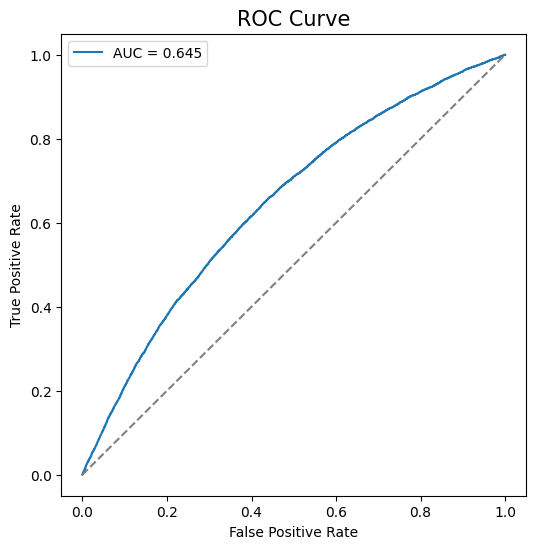

In [158]:
fpr, tpr, tr = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label='AUC = %0.3f' %auc)
plt.plot(fpr, fpr, linestyle = '--', color='grey')
plt.xlabel('False Positive Rate', fontsize=10)
plt.ylabel('True Positive Rate', fontsize=10)
plt.title('ROC Curve', fontsize=15)
plt.legend()

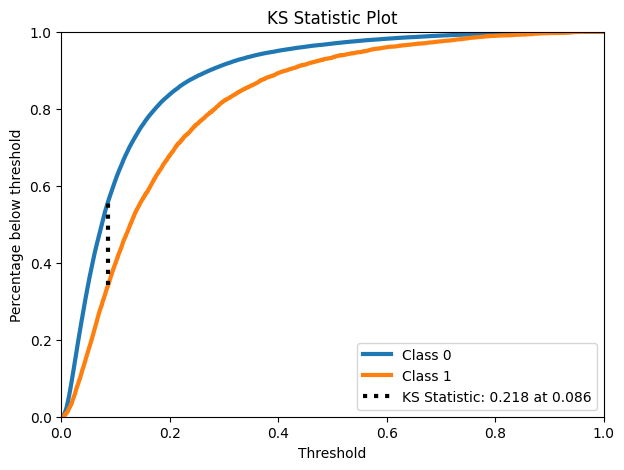

In [159]:
y_pred_proba = lr_tuning.predict_proba(x_test)

skplt.metrics.plot_ks_statistic(y_test, y_pred_proba, figsize=(7,5));

scale_pos_weight: 11.329991980753809
Fitting 5 folds for each of 72 candidates, totalling 360 fits


C:\Users\abiyy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:199: UserWarning: [14:16:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best AUC (CV): 0.9704364888443846
Test ROC AUC: 0.6539779448474119


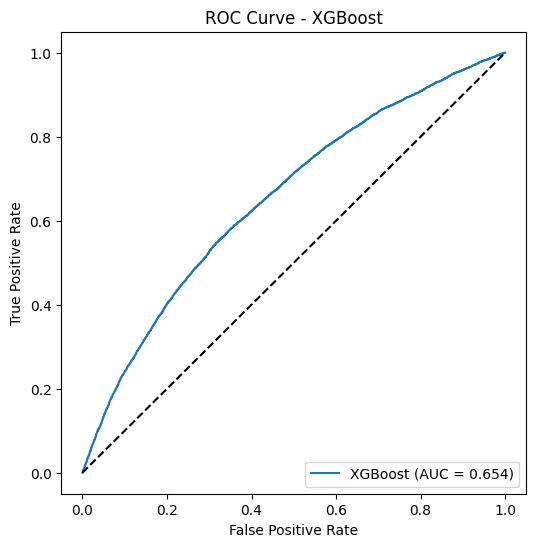

In [160]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split

# === 2. Hitung scale_pos_weight ===
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
print("scale_pos_weight:", scale_pos_weight)

# === 3. Definisikan model dasar ===
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# === 4. Hyperparameter Grid ===
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# === 5. Stratified K-Fold ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=4)

# === 6. GridSearchCV ===
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=skf,
    verbose=2,
    n_jobs=-1,
    refit=True
)

# Latih dengan data hasil SMOTE
grid.fit(x_smote.values, y_smote.values)

print("Best Parameters:", grid.best_params_)
print("Best AUC (CV):", grid.best_score_)

# === 7. Evaluasi di Test Set ===
best_model = grid.best_estimator_
y_pred_proba = best_model.predict_proba(x_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print("Test ROC AUC:", auc)

# === 8. Plot ROC Curve ===
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.show()

In [161]:
df_importance = pd.read_html(est2.summary().tables[1].as_html(),header=0,index_col=0)[0]

# find odds_ratio
for i in df_importance['coef']:
    if i == 0 :
        df_importance['odds_ratio'] = 0
    else:
        df_importance['odds_ratio'] = np.exp(df_importance['coef'])

# show top 5 highest odd ratio
df_importance.iloc[1:,:].sort_values(by='odds_ratio', ascending=False).head(10)

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\3706568670.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_importance = pd.read_html(est2.summary().tables[1].as_html(),header=0,index_col=0)[0]


,coef,std err,t,P>|t|,[0.025,0.975],odds_ratio
CODE_GENDER,3.480000e-02,1.000000e-03,32.109,0.000,3.300000e-02,3.700000e-02,1.035413
REGION_POPULATION_RELATIVE_4,-2.541000e-16,7.760000e-16,-0.327,0.743,-1.770000e-15,1.270000e-15,1.000000
CNT_FAM_MEMBERS_10-15,-8.500000e-03,1.290000e-01,-0.066,0.947,-2.610000e-01,2.440000e-01,0.991536
OBS_30_CNT_SOCIAL_CIRCLE_>20,-1.880000e-02,3.400000e-02,-0.551,0.581,-8.600000e-02,4.800000e-02,0.981376
OBS_30_CNT_SOCIAL_CIRCLE_>5,-2.550000e-02,1.000000e-02,-2.536,0.011,-4.500000e-02,-6.000000e-03,0.974822
OBS_60_CNT_SOCIAL_CIRCLE_>1,-3.260000e-02,1.000000e-02,-3.297,0.001,-5.200000e-02,-1.300000e-02,0.967926
OBS_30_CNT_SOCIAL_CIRCLE_>10,-3.490000e-02,1.200000e-02,-2.839,0.005,-5.900000e-02,-1.100000e-02,0.965702
OBS_30_CNT_SOCIAL_CIRCLE_>1,-3.820000e-02,1.000000e-02,-3.863,0.000,-5.800000e-02,-1.900000e-02,0.962520
FLAG_OWN_CAR,-4.220000e-02,1.000000e-03,-37.722,0.000,-4.400000e-02,-4.000000e-02,0.958678
OBS_60_CNT_SOCIAL_CIRCLE_0,-4.330000e-02,9.000000e-03,-5.094,0.000,-6.000000e-02,-2.700000e-02,0.957624


In [162]:
# === 1. Definisikan model terbaik (misalnya hasil tuning) ===
xgb_best = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=7,
    n_estimators=200,
    subsample=0.8,
    random_state=42
)

# === 2. Latih model dengan data train ===
xgb_best.fit(x_smote.values, y_smote.values)

# === 3. Prediksi probabilitas ===
y_train_pred_proba = xgb_best.predict_proba(x_train)[:, 1]
y_test_pred_proba  = xgb_best.predict_proba(x_test)[:, 1]

# === 4. Hitung AUC Train & Test ===
print("AUC Train Proba :", roc_auc_score(y_train, y_train_pred_proba))
print("AUC Test Proba  :", roc_auc_score(y_test, y_test_pred_proba))


C:\Users\abiyy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:199: UserWarning: [14:16:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC Train Proba : 0.7790342430325674
AUC Test Proba  : 0.6521908334549416


In [163]:
data_to_predict = df_encod
data_to_predict.shape

(307511, 75)

In [164]:
print("Training features:", xgb_best.n_features_in_)
print("Prediction features:", data_to_predict.shape[1])
print("Columns difference:", set(data_to_predict.columns) - set(x_train.columns))

Training features: 75
Prediction features: 75
Columns difference: set()


In [165]:
data_to_predict = data_to_predict[x_train.columns]

In [166]:
data_to_predict = data_to_predict.drop(columns=['TARGET'], errors='ignore')

In [167]:
df_predicted = xgb_best.predict_proba(data_to_predict)[:][:,1]
df_predicted

array([0.7637481 , 0.21831657, 0.52147776, ..., 0.25463596, 0.99999845,
       0.99999845], dtype=float32)

In [168]:
# set new index
df_importance = df_importance.reset_index()

# rename columns
df_importance = df_importance.rename(columns = {'index' : 'feature'})

# creat new columns feature_name (stand for original feature name)
df_importance['feature_name'] = df_importance['feature']

df_importance['feature_name'][3:9] = 'AMT_INCOME_TOTAL'
df_importance['feature_name'][9:15] = 'AMT_CREDIT'
df_importance['feature_name'][15:19] = 'AMT_ANNUITY'
df_importance['feature_name'][19:23] = 'AMT_GOODS_PRICE'
df_importance['feature_name'][23:27] = 'REGION_POPULATION_RELATIVE'
df_importance['feature_name'][27:31] = 'CNT_FAM_MEMBERS'
df_importance['feature_name'][31:35] = 'HOUR_APPR_PROCESS_START'
df_importance['feature_name'][35:39] = 'EXT_SOURCE_2'
df_importance['feature_name'][39:44] = 'EXT_SOURCE_3'
df_importance['feature_name'][44:47] = 'OBS_30_CNT_SOCIAL_CIRCLE'
df_importance['feature_name'][47:50] = 'OBS_60_CNT_SOCIAL_CIRCLE'
df_importance['feature_name'][50:53] = 'AMT_REQ_CREDIT_BUREAU_YEAR'
df_importance['feature_name'][53:58] = 'AGE'
df_importance['feature_name'][58:65] = 'YEAR_EMP'
df_importance['feature_name'][65:72] = 'YEAR_REGISTERED'
df_importance['feature_name'][72:76] = 'YEAR_PUBLISHED'
df_importance['feature_name'][76:80] = 'YEAR_LAST_PHONE_CHANGE'

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\3779580089.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_importance['feature_name'][3:9] = 'AMT_INCOME_TOTAL'
C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\3779580089.py:10: Set

In [169]:
df_scorecard = df_importance.copy()

# define max and min score
min_score = 300
max_score = 850

In [170]:
# aggregate min and sum
min_sum_coef = df_scorecard.groupby('feature_name')['coef'].min().sum()

# aggregate max and sum
max_sum_coef = df_scorecard.groupby('feature_name')['coef'].max().sum()

# define credit score
df_scorecard['Score - Calculation'] = df_scorecard['coef'] * (max_score - min_score) / (max_sum_coef - min_sum_coef)

# adjust intercept values
df_scorecard['Score - Calculation'][0] = ((df_scorecard['coef'][0] - min_sum_coef) / ((max_sum_coef - min_sum_coef)) * (max_score - min_score) + min_score)

# round credit score
df_scorecard['Score - Preliminary'] = df_scorecard['Score - Calculation'].round()

C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\1197336565.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_scorecard['Score - Calculation'][0] = ((df_scorecard['coef'][0] - min_sum_coef) / ((max_sum_coef - min_sum_coef)) * (max_sco

In [171]:
min_sum_score_prel = df_scorecard.groupby('feature_name')['Score - Preliminary'].min().sum()
# check max score, it should be = 850
max_sum_score_prel = df_scorecard.groupby('feature_name')['Score - Preliminary'].max().sum()

print('min score', min_sum_score_prel)
print('max score', max_sum_score_prel)

min score 300.0
max score 849.0


In [172]:
df_scorecard['Difference'] = df_scorecard['Score - Preliminary'] - df_scorecard['Score - Calculation']

In [173]:
df_scorecard['Score - Final'] = df_scorecard['Score - Preliminary']
df_scorecard['Score - Final'][4] = -107
df_scorecard['Score - Final'][8] = -132

# check min score, it shoud be = 300
min_sum_score_prel = df_scorecard.groupby('feature_name')['Score - Final'].min().sum()
# check max score, it should be = 850
max_sum_score_prel = df_scorecard.groupby('feature_name')['Score - Final'].max().sum()

print('min score', min_sum_score_prel)
print('max score', max_sum_score_prel)

min score 247.0
max score 847.0


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\3975045074.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_scorecard['Score - Final'][4] = -107
C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\3975045074.py:2: SettingWithCopyWarnin

In [174]:
# define data
df = data_to_predict
df.head()

,CODE_GENDER,FLAG_OWN_CAR,AMT_INCOME_TOTAL_<100k,AMT_INCOME_TOTAL_100k>,AMT_INCOME_TOTAL_150k>,AMT_INCOME_TOTAL_200k>,AMT_INCOME_TOTAL_250k>,AMT_INCOME_TOTAL_>_300k,AMT_CREDIT_<200k,AMT_CREDIT_200k>,AMT_CREDIT_400k>,AMT_CREDIT_600k>,AMT_CREDIT_800k>,AMT_CREDIT_>1m,AMT_ANNUITY_<20k,AMT_ANNUITY_20k>,AMT_ANNUITY_30k>,AMT_ANNUITY_46k>,AMT_GOODS_PRICE_<300k,AMT_GOODS_PRICE_300k>,AMT_GOODS_PRICE_600k>,AMT_GOODS_PRICE_900k>,REGION_POPULATION_RELATIVE_1,REGION_POPULATION_RELATIVE_2,REGION_POPULATION_RELATIVE_3,REGION_POPULATION_RELATIVE_4,REGION_POPULATION_RELATIVE_>4,CNT_FAM_MEMBERS_1-5,CNT_FAM_MEMBERS_5-10,CNT_FAM_MEMBERS_10-15,CNT_FAM_MEMBERS_15-20,HOUR_APPR_PROCESS_START_0_6,HOUR_APPR_PROCESS_START_6_12,HOUR_APPR_PROCESS_START_12_18,HOUR_APPR_PROCESS_START_>18,EXT_SOURCE_2_2,EXT_SOURCE_2_2_4,EXT_SOURCE_2_4_6,EXT_SOURCE_2_>6,OBS_30_CNT_SOCIAL_CIRCLE_0,OBS_30_CNT_SOCIAL_CIRCLE_>1,OBS_30_CNT_SOCIAL_CIRCLE_>5,OBS_30_CNT_SOCIAL_CIRCLE_>10,OBS_30_CNT_SOCIAL_CIRCLE_>20,OBS_30_CNT_SOCIAL_CIRCLE_>30,OBS_60_CNT_SOCIAL_CIRCLE_0,OBS_60_CNT_SOCIAL_CIRCLE_>1,OBS_60_CNT_SOCIAL_CIRCLE_>5,OBS_60_CNT_SOCIAL_CIRCLE_>7,AMT_REQ_CREDIT_BUREAU_YEAR_0,AMT_REQ_CREDIT_BUREAU_YEAR_>1,AMT_REQ_CREDIT_BUREAU_YEAR_>2,AMT_REQ_CREDIT_BUREAU_YEAR_>3,YEARS_BIRTH_>20,YEARS_BIRTH_>30,YEARS_BIRTH_>40,YEARS_BIRTH_>50,YEARS_BIRTH_>60,YEARS_EMPLOYED_0-4,YEARS_EMPLOYED_4-16,YEARS_EMPLOYED_16-30,YEARS_EMPLOYED_30++,YEARS_REGISTRATION_0-2,YEARS_REGISTRATION_2-4,YEARS_REGISTRATION_4-8,YEARS_REGISTRATION_8-16,YEARS_REGISTRATION_16-30,YEARS_REGISTRATION_30++,YEARS_PUBLISH_0-4,YEARS_PUBLISH_4-8,YEARS_PUBLISH_8-12,YEARS_PUBLISH_12++,YEARS_LAST_PHONE_CHANGE_0-4,YEARS_LAST_PHONE_CHANGE_4-8,YEARS_LAST_PHONE_CHANGE_8-12
0,1.0,0.0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0
1,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0
2,1.0,1.0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0
3,0.0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0
4,1.0,0.0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0


In [175]:
df.insert(0, 'Intercept', 1)

In [176]:
# define score card
scorecard_scores = df_scorecard['Score - Final']

# reshape
scorecard_scores = scorecard_scores.values.reshape(76, 1)

In [177]:
y_scores = df.dot(scorecard_scores)

In [178]:
# concat
score_card_df = pd.concat([df, y_scores], axis=1)

# rename
score_card_df.rename(columns={0:'Credit Score'}, inplace=True)

# show
score_card_df.head(5)

,Intercept,CODE_GENDER,FLAG_OWN_CAR,AMT_INCOME_TOTAL_<100k,AMT_INCOME_TOTAL_100k>,AMT_INCOME_TOTAL_150k>,AMT_INCOME_TOTAL_200k>,AMT_INCOME_TOTAL_250k>,AMT_INCOME_TOTAL_>_300k,AMT_CREDIT_<200k,AMT_CREDIT_200k>,AMT_CREDIT_400k>,AMT_CREDIT_600k>,AMT_CREDIT_800k>,AMT_CREDIT_>1m,AMT_ANNUITY_<20k,AMT_ANNUITY_20k>,AMT_ANNUITY_30k>,AMT_ANNUITY_46k>,AMT_GOODS_PRICE_<300k,AMT_GOODS_PRICE_300k>,AMT_GOODS_PRICE_600k>,AMT_GOODS_PRICE_900k>,REGION_POPULATION_RELATIVE_1,REGION_POPULATION_RELATIVE_2,REGION_POPULATION_RELATIVE_3,REGION_POPULATION_RELATIVE_4,REGION_POPULATION_RELATIVE_>4,CNT_FAM_MEMBERS_1-5,CNT_FAM_MEMBERS_5-10,CNT_FAM_MEMBERS_10-15,CNT_FAM_MEMBERS_15-20,HOUR_APPR_PROCESS_START_0_6,HOUR_APPR_PROCESS_START_6_12,HOUR_APPR_PROCESS_START_12_18,HOUR_APPR_PROCESS_START_>18,EXT_SOURCE_2_2,EXT_SOURCE_2_2_4,EXT_SOURCE_2_4_6,EXT_SOURCE_2_>6,OBS_30_CNT_SOCIAL_CIRCLE_0,OBS_30_CNT_SOCIAL_CIRCLE_>1,OBS_30_CNT_SOCIAL_CIRCLE_>5,OBS_30_CNT_SOCIAL_CIRCLE_>10,OBS_30_CNT_SOCIAL_CIRCLE_>20,OBS_30_CNT_SOCIAL_CIRCLE_>30,OBS_60_CNT_SOCIAL_CIRCLE_0,OBS_60_CNT_SOCIAL_CIRCLE_>1,OBS_60_CNT_SOCIAL_CIRCLE_>5,OBS_60_CNT_SOCIAL_CIRCLE_>7,AMT_REQ_CREDIT_BUREAU_YEAR_0,AMT_REQ_CREDIT_BUREAU_YEAR_>1,AMT_REQ_CREDIT_BUREAU_YEAR_>2,AMT_REQ_CREDIT_BUREAU_YEAR_>3,YEARS_BIRTH_>20,YEARS_BIRTH_>30,YEARS_BIRTH_>40,YEARS_BIRTH_>50,YEARS_BIRTH_>60,YEARS_EMPLOYED_0-4,YEARS_EMPLOYED_4-16,YEARS_EMPLOYED_16-30,YEARS_EMPLOYED_30++,YEARS_REGISTRATION_0-2,YEARS_REGISTRATION_2-4,YEARS_REGISTRATION_4-8,YEARS_REGISTRATION_8-16,YEARS_REGISTRATION_16-30,YEARS_REGISTRATION_30++,YEARS_PUBLISH_0-4,YEARS_PUBLISH_4-8,YEARS_PUBLISH_8-12,YEARS_PUBLISH_12++,YEARS_LAST_PHONE_CHANGE_0-4,YEARS_LAST_PHONE_CHANGE_4-8,YEARS_LAST_PHONE_CHANGE_8-12,Credit Score
0,1,1.0,0.0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,617.0
1,1,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,584.0
2,1,1.0,1.0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,626.0
3,1,0.0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,527.0
4,1,1.0,0.0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,603.0


In [179]:
# join id based on index
simulation_index = df_Apptest.copy()
simulation_index = simulation_index['SK_ID_CURR']

simulation_index.shape, score_card_df.shape

((48744,), (307511, 77))

In [180]:
credit_score_w_id = pd.merge(simulation_index, score_card_df, left_index = True, right_index = True)
credit_score_w_id = credit_score_w_id[['SK_ID_CURR','Credit Score']]
credit_score_w_id.head()

,SK_ID_CURR,Credit Score
0,100001,617.0
1,100005,584.0
2,100013,626.0
3,100028,527.0
4,100038,603.0


In [181]:
credit_score_w_id.sample(5)

,SK_ID_CURR,Credit Score
30863,324222,527.0
35523,360074,636.0
48072,451235,559.0
7818,157428,564.0
29721,316297,667.0


In [182]:
# converting FICO scale to 100% scale
sum_coef_from_score = ((y_scores - min_score) / (max_score - min_score)) * (max_sum_coef - min_sum_coef) + min_sum_coef

credit_score_pctg_scale = np.exp(sum_coef_from_score) / (np.exp(sum_coef_from_score) + 1)

# concat
score_card_df_pctg = pd.merge(simulation_index, credit_score_pctg_scale, left_index = True, right_index = True)

# rename
score_card_df_pctg.rename(columns={0:'Credit Score'}, inplace=True)
score_card_df_pctg.head()

,SK_ID_CURR,Credit Score
0,100001,0.574603
1,100005,0.536070
2,100013,0.584976
3,100028,0.468755
4,100038,0.558338


In [183]:
score_card_df_pctg.sample(5)

,SK_ID_CURR,Credit Score
20998,252425,0.478190
41911,407033,0.505380
43379,415548,0.455819
23651,271969,0.466400
38961,386860,0.575759


In [184]:
x_feature_selc_copy['CNT_FAM_MEMBERS_FC'] = np.where(
    x_feature_selc['CNT_FAM_MEMBERS'] == 2, '2 person',
    np.where(x_feature_selc['CNT_FAM_MEMBERS'] <= 4, '2-4 person',
    np.where(x_feature_selc['CNT_FAM_MEMBERS'] <= 6, '4-6 person', '>6 person'))
)

x_feature_selc_copy['CNT_FAM_MEMBERS_FC'].value_counts()


CNT_FAM_MEMBERS_FC
2 person      158357
2-4 person    145145
4-6 person      3886
>6 person        123
Name: count, dtype: int64

Text(0.5, 1.0, 'Count Family Members')

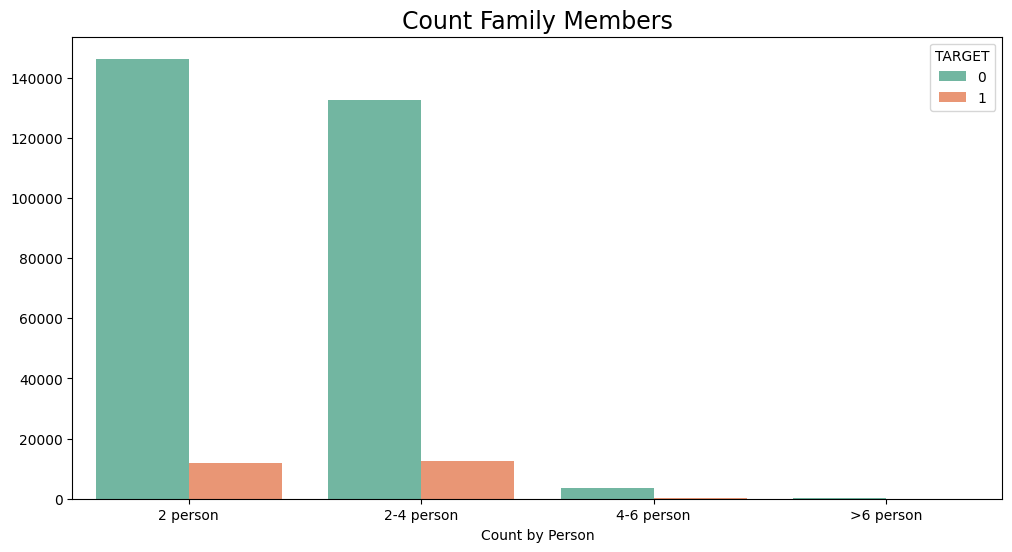

In [216]:
plt.figure(figsize=(12,6))
sns.countplot(
    x='CNT_FAM_MEMBERS_FC',
    hue='TARGET',
    data=x_feature_selc_copy,
    order=['2 person','2-4 person','4-6 person','>6 person'],
    palette='Set2'
)
plt.xlabel('Count by Person')
plt.ylabel('')
plt.title('Count Family Members', fontsize=17)
# plt.savefig('figure11.png', dpi=500, bbox_inches='tight', pad_inches=0.2, transparent=True)


In [186]:
df_fam = (
    x_feature_selc_copy
    .groupby(['CNT_FAM_MEMBERS_FC','TARGET'])
    .agg(COUNT=('TARGET','count'))
    .reset_index()
)

df_fam['PERCENT'] = round(
    df_fam['COUNT'] / df_fam.groupby('CNT_FAM_MEMBERS_FC')['COUNT'].transform('sum') * 100, 2
)

df_fam

,CNT_FAM_MEMBERS_FC,TARGET,COUNT,PERCENT
0,2 person,0,146348,92.42
1,2 person,1,12009,7.58
2,2-4 person,0,132726,91.44
3,2-4 person,1,12419,8.56
4,4-6 person,0,3504,90.17
5,4-6 person,1,382,9.83
6,>6 person,0,108,87.80
7,>6 person,1,15,12.20


In [187]:
x_feature_selc_copy['AMT_GOODS_PRICE_FC'] = np.where(
    x_feature_selc['AMT_GOODS_PRICE'] <= 300000, '<300k',
    np.where(x_feature_selc['AMT_GOODS_PRICE'] <= 600000, '300k-600k',
    np.where(x_feature_selc['AMT_GOODS_PRICE'] <= 900000, '600k-900k', '>900k'))
)

x_feature_selc_copy['AMT_GOODS_PRICE_FC'].value_counts()

AMT_GOODS_PRICE_FC
<300k        104426
300k-600k     91585
600k-900k     69618
>900k         41882
Name: count, dtype: int64

Text(0.5, 1.0, 'Price of the goods financed by the loan')

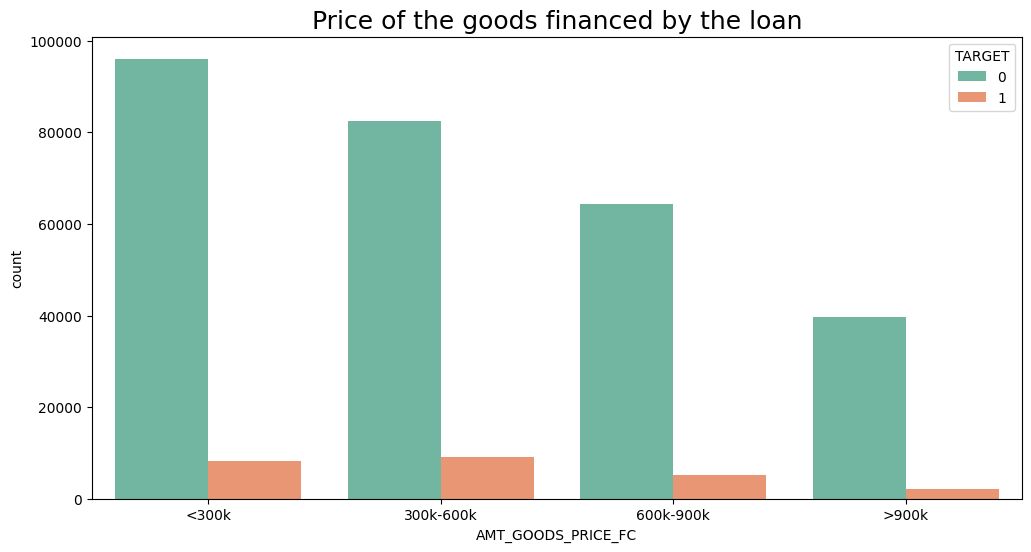

In [215]:
plt.figure(figsize=(12,6))
sns.countplot(
    x='AMT_GOODS_PRICE_FC',
    hue='TARGET',
    data=x_feature_selc_copy,
    order=['<300k','300k-600k','600k-900k','>900k'],
    palette='Set2'
)
plt.title('Price of the goods financed by the loan', fontsize=18)
# plt.savefig('figure12.png', dpi=500, bbox_inches='tight', pad_inches=0.2, transparent=True)

In [189]:
df_fam = (
    x_feature_selc_copy
    .groupby(['AMT_GOODS_PRICE_FC','TARGET'])
    .agg(COUNT=('TARGET','count'))
    .reset_index()
)

df_fam['PERCENT'] = round(
    df_fam['COUNT'] / df_fam.groupby('AMT_GOODS_PRICE_FC')['COUNT'].transform('sum') * 100, 2
)

df_fam

,AMT_GOODS_PRICE_FC,TARGET,COUNT,PERCENT
0,300k-600k,0,82454,90.03
1,300k-600k,1,9131,9.97
2,600k-900k,0,64408,92.52
3,600k-900k,1,5210,7.48
4,<300k,0,96083,92.01
5,<300k,1,8343,7.99
6,>900k,0,39741,94.89
7,>900k,1,2141,5.11


In [195]:
df_fam["SK_ID_BUREAU"] = df_fam["SK_ID_BUREAU"].astype("int32")
chunk["SK_ID_BUREAU"] = chunk["SK_ID_BUREAU"].astype("int32")

In [208]:
df_fam = pd.merge(df_Apptrain, df_Bureau , left_on='SK_ID_CURR', right_on='SK_ID_CURR')
df_gen = pd.merge(df_fam, df_Bureau_balance, left_on='SK_ID_BUREAU', right_on='SK_ID_BUREAU')

In [209]:
df_gen ['CODE_GENDER'] = np.where(df_gen ['CODE_GENDER']=='XNA','F',df_gen ['CODE_GENDER'])
df_gen ['CODE_GENDER'].value_counts()

CODE_GENDER
F    9925437
M    4776175
Name: count, dtype: int64

In [210]:
df_for = df_gen[df_gen['FLAG_OWN_CAR']=='Y']

In [225]:
df_fortar.value_counts()

FLAG_OWN_CAR  CODE_GENDER  TARGET  PERCENT  VALUES          
Y             F            139095  2.0      Female Owner Car    1
              M            221958  4.0      Male Owner Car      1
Name: count, dtype: int64

In [226]:
df_fortar = df_for.groupby(['FLAG_OWN_CAR','CODE_GENDER'])['TARGET'].sum().reset_index()
df_fortar['PERCENT'] = round(df_fortar['TARGET']/(139095+221958)*100)
df_fortar['VALUES'] = ['Female Owner Car', 'Male Owner Car']
df_fortar

,FLAG_OWN_CAR,CODE_GENDER,TARGET,PERCENT,VALUES
0,Y,F,139095,39.0,Female Owner Car
1,Y,M,221958,61.0,Male Owner Car


C:\Users\abiyy\AppData\Local\Temp\ipykernel_19464\246920000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VALUES', y='PERCENT', data=df_fortar, palette='Set2')


Text(0.5, 1.0, 'Ratio Payment Difficulties')

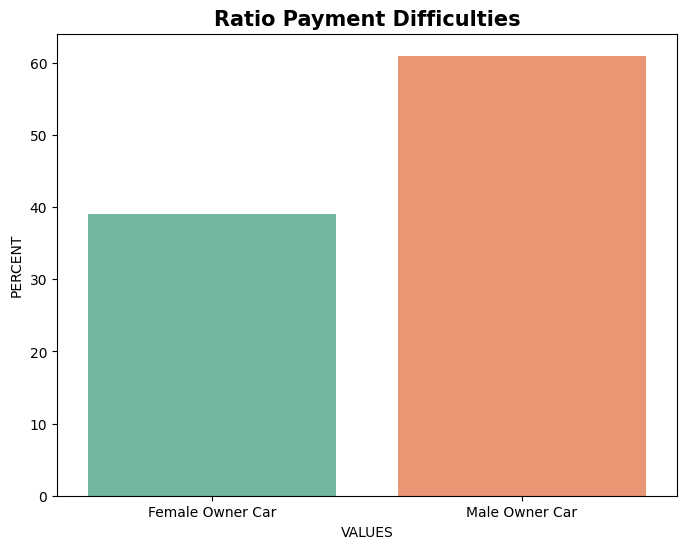

In [222]:
plt.figure(figsize=(8,6))
sns.barplot(x='VALUES', y='PERCENT', data=df_fortar, palette='Set2')
plt.title('Ratio Payment Difficulties', fontsize=15, weight='bold')